# Demo 4: Reducing data to a single dimension based on distance to a control behavior distribution

Sedona Ewbank (snewbank@stanford.edu), 24-07-29

## Import dependencies

In [6]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy
from scipy import optimize, stats, special
import numpy as np
import importlib
import os
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

#import utils
from utils import analysis, plot, metadata

importlib.reload(analysis)
importlib.reload(plot)
importlib.reload(metadata)

<module 'utils.metadata' from '/Users/snewbank/PycharmProjects/MARIPOSA/utils/metadata.py'>

In [7]:
# import sys
# sys.path.append("/Users/snewbank/PycharmProjects/")
# from MARIPOSA.utils import analysis, metadata, plot

## Exercise 1: Dose-response

In [4]:
importlib.reload(analysis)
importlib.reload(plot)

config_path="/Users/snewbank/Behavior/MARIPOSA_test/240605_240605_BSOID-test/config.yaml"
save_path="/Users/snewbank/Behavior/MARIPOSA_test/240605_240605_BSOID-test/demo/"
save=False

#Load config
config = metadata.load_project(config_path)

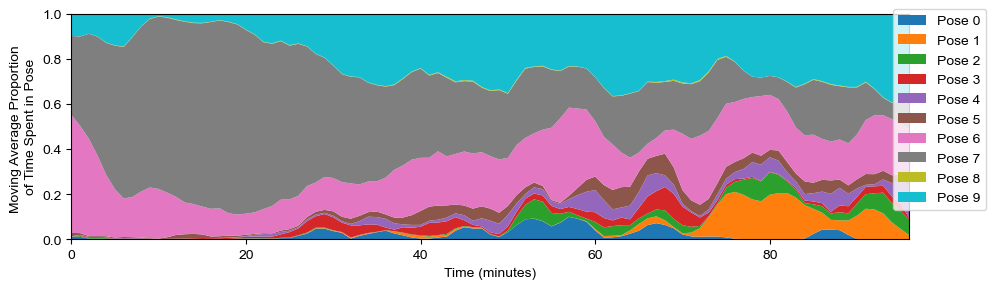

In [5]:
group="k10"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 30, 100)

In [280]:
labels_df, n_modules = analysis.label_counter_subgroups(config,0,3600,selected_subgroups=["k10"])
#fig = plot.plot_module_usage_subgroups(config, labels_df, 0, 3600)

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

def module_usage_density(config,
                         labels_df,
                         start,
                         time_per_block,
                         n_blocks,
                         posenames=None,
                         convolve=4):
    """
    Plots usage of pose modules over time within a session
    :param labels_df:
    :param start: time to start at in seconds
    :param time_per_block: time per block in seconds
    :param fps: frames per second
    :param n_blocks:
    :param figW:
    :param figH:
    :param posenames:
    :param title:
    :param convolve:
    :param legend:
    :param plottype:
    :param saveplots:
    :param savename:
    :return:
    """
    fps = config["fps"]
    n_samples = len(labels_df.columns)
    labels_flat = np.array(labels_df)
    labels_flat = [item for sublist in labels_flat for item in sublist]
    clusts = np.unique(labels_flat)
    n_clust = len(clusts)
    block_labels = np.zeros([n_samples, n_clust, n_blocks])
    block_labels_normal = np.zeros([n_samples, n_clust, n_blocks])
    block_labels_normal_conv = np.zeros([n_samples, n_clust, n_blocks-(convolve-1)])
    frames_per_block = int(fps * time_per_block)
    for i in range(n_samples):
        for b in range(n_blocks):
            new_start = start + b * frames_per_block
            x = labels_df[labels_df.columns[i]][new_start:new_start + frames_per_block]
            for q in range(n_clust):
                block_labels[i, q, b] = np.count_nonzero(x == q)
                block_labels_normal[i, q, b] = np.count_nonzero(x == q) / frames_per_block
        for q in range(n_clust):
            #print(block_labels_normal[i, q, :])
            block_labels_normal_conv[i, q, :] = moving_average(block_labels_normal[i, q, :],convolve)
        

    return block_labels_normal, block_labels_normal_conv

# block_labels_normal = module_usage_density(config, labels_df["k10"],0, 30, 100)
# block_labels_normal.shape

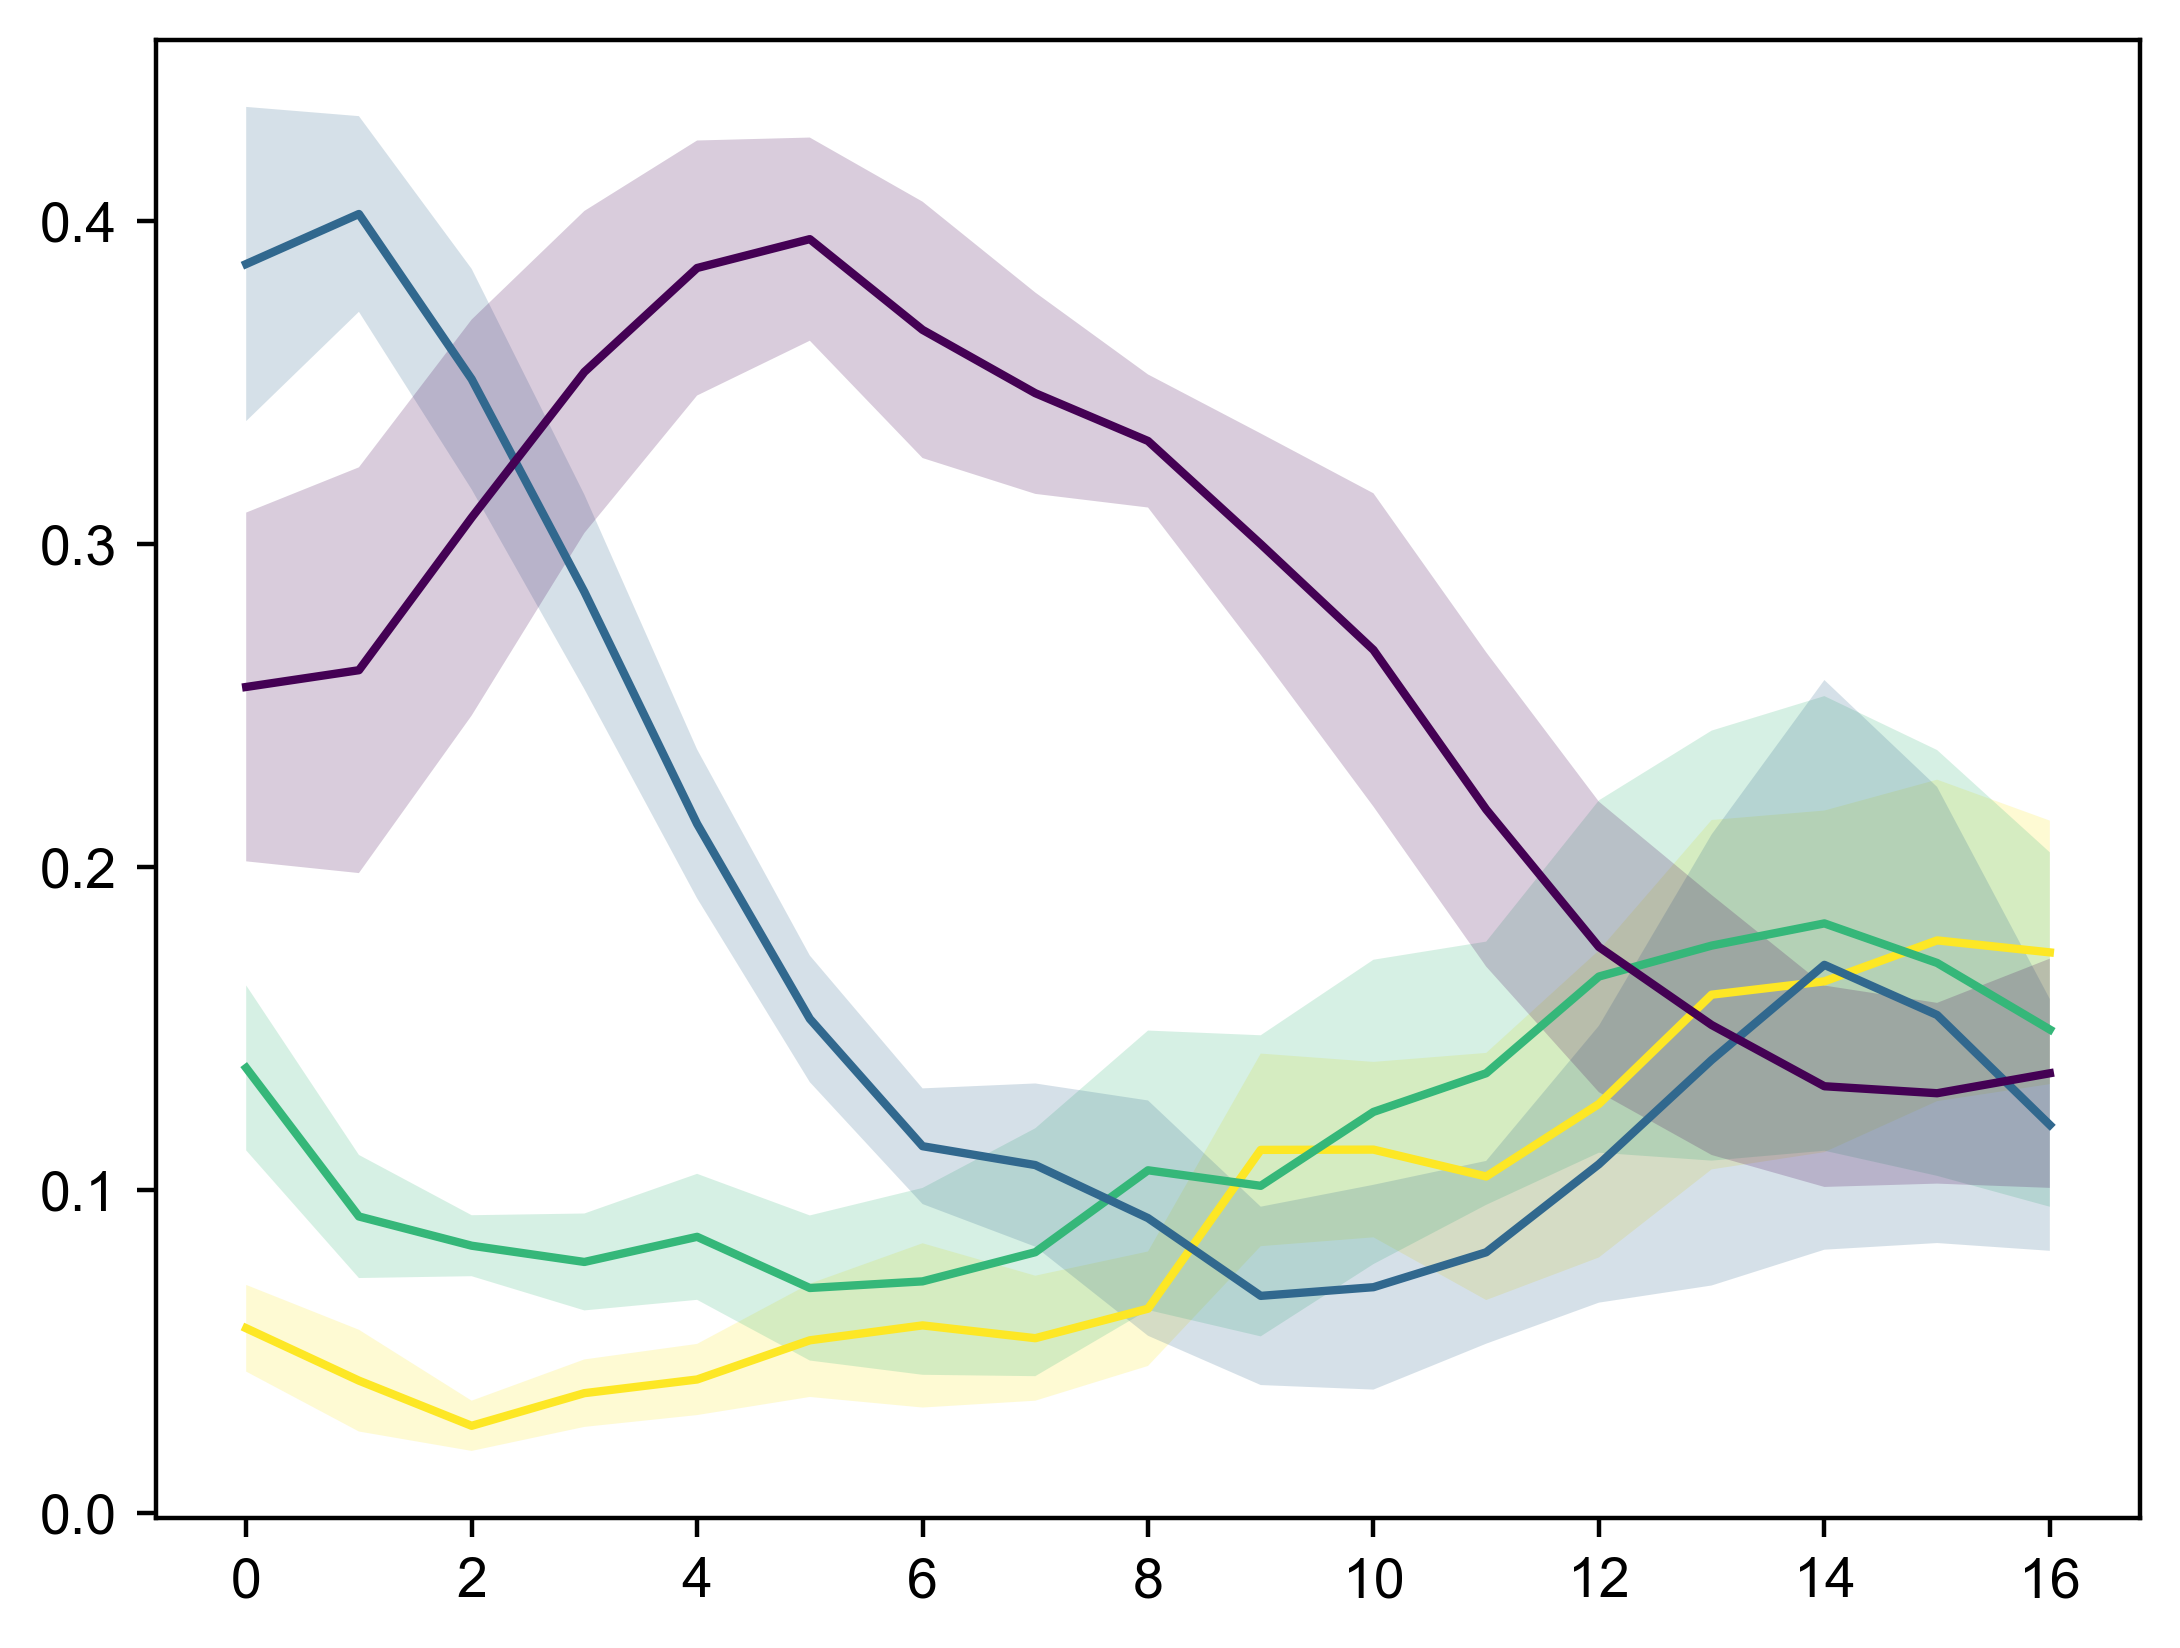

In [281]:
def module_usage_dist(config,labels_df):
    """
    Gives frequency of pose module usage
    :param labels_df: dataframe output from analysis.label_counter
    :return:
    """
    fps = config["fps"]
    total_frames = labels_df.shape[0]
    labels_flat = np.array(labels_df)
    labels_flat = [item for sublist in labels_flat for item in sublist]
    modules = np.unique(labels_flat)
    n_modules = len(modules)

    label_counts = np.zeros([labels_df.shape[1], n_modules])
    for i in range(labels_df.shape[1]):
        for m in range(n_modules):
            module = modules[m]
            try:
                module = np.int64(module)
            except ValueError:
                pass
            label_counts[i,m] = np.count_nonzero \
                (labels_df[[labels_df.columns[i]]] == module) /total_frames
    bar_heights = np.mean(label_counts,axis=0)
    bar_sems = np.std(label_counts,axis=0)/np.sqrt(labels_df.shape[1])
    return label_counts


groups=["sal","k1","k5","k10"]
cmap = plt.get_cmap("viridis_r")
colors = [cmap([i]) for i in np.linspace(0,1,len(groups))]

plt.figure(dpi=400)
for g, group in enumerate(groups):
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=[group])
    block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df[group],0, 60, 20)
    block_labels_normal.shape
    
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["sal"])
    label_counts=module_usage_dist(config,labels_df)
    mean_label_counts=np.mean(label_counts,axis=0)
    
    mean_label_counts_block = np.expand_dims(mean_label_counts, axis=1)
    mean_label_counts_block = np.tile(mean_label_counts_block, (1, block_labels_normal.shape[2]))
    
    out=np.zeros_like(block_labels_normal)
    for sess in range(block_labels_normal.shape[0]):
        out[sess,:,:]=np.square(block_labels_normal[sess,:,:]-mean_label_counts_block)
    
    dist=np.sum(out,axis=1)
    xpts=np.arange(0,dist.shape[1],1)
    
    mean = np.mean(dist,axis=0)
    sem = np.std(dist,axis=0)/np.sqrt(dist.shape[0])
    
    plt.plot(xpts,mean,label=group,color=colors[g])
    plt.fill_between(xpts,mean-sem,mean+sem,alpha=0.2,color=colors[g],edgecolor="none")

## Exercise 2: Routes of administration

In [282]:
IV=["R1","R4","R7","R10","R13","R14"]
SC=["R2","R5","R8","R11"]
IP=["R3","R6","R9","R12"]

def load_pk(pk_path,drops=True):
    df = pd.read_csv(pk_path,index_col="Time")
    df = df.apply(pd.to_numeric, errors='coerce')
    df
    if drops==True:
        df.at[1.0,"R13"]=np.nan
        df.at[1.0,"R3"]=np.nan
        df.at[2.5,"R3"]=np.nan
        df.at[5.0,"R3"]=np.nan
        df.at[10.0,"R3"]=np.nan
        df.at[20.0,"R3"]=np.nan
        df.at[40.0,"R3"]=np.nan
        df.at[60.0,"R3"]=np.nan
        df.at[62.0,"R3"]=np.nan
    df.drop(index=62.0,inplace=True)
    return df

pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_ketblood_ROAs.csv"
df=load_pk(pk_path)
df[IP]

,R3,R6,R9,R12
Time,,,,
1.0,NaN,29.709230,5.143619,15.073412
2.5,NaN,31.183018,9.712859,36.854782
5.0,NaN,40.450747,23.968460,65.692727
10.0,NaN,62.922015,40.143471,76.566326
20.0,NaN,60.196389,54.486061,79.122893
40.0,NaN,41.744157,53.380320,59.161757
60.0,NaN,35.904290,50.103677,47.952969


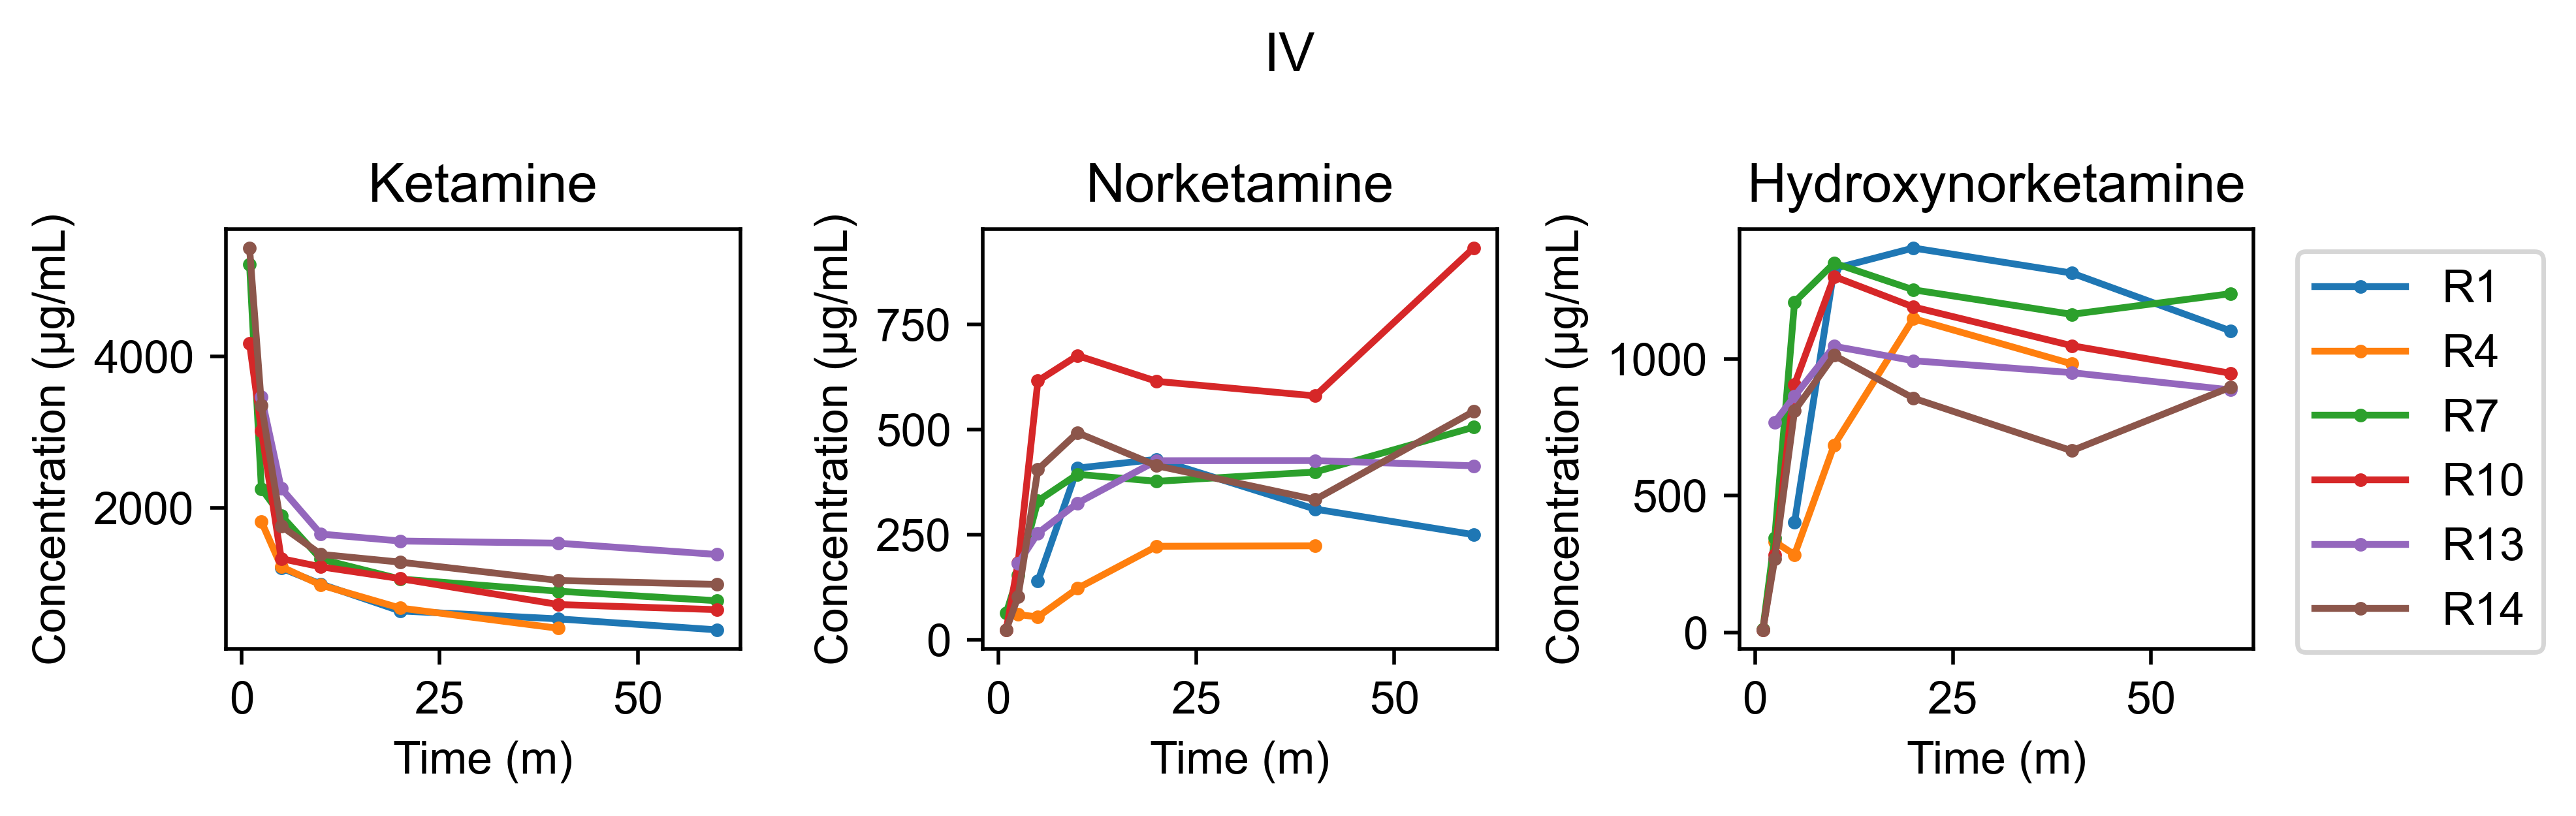

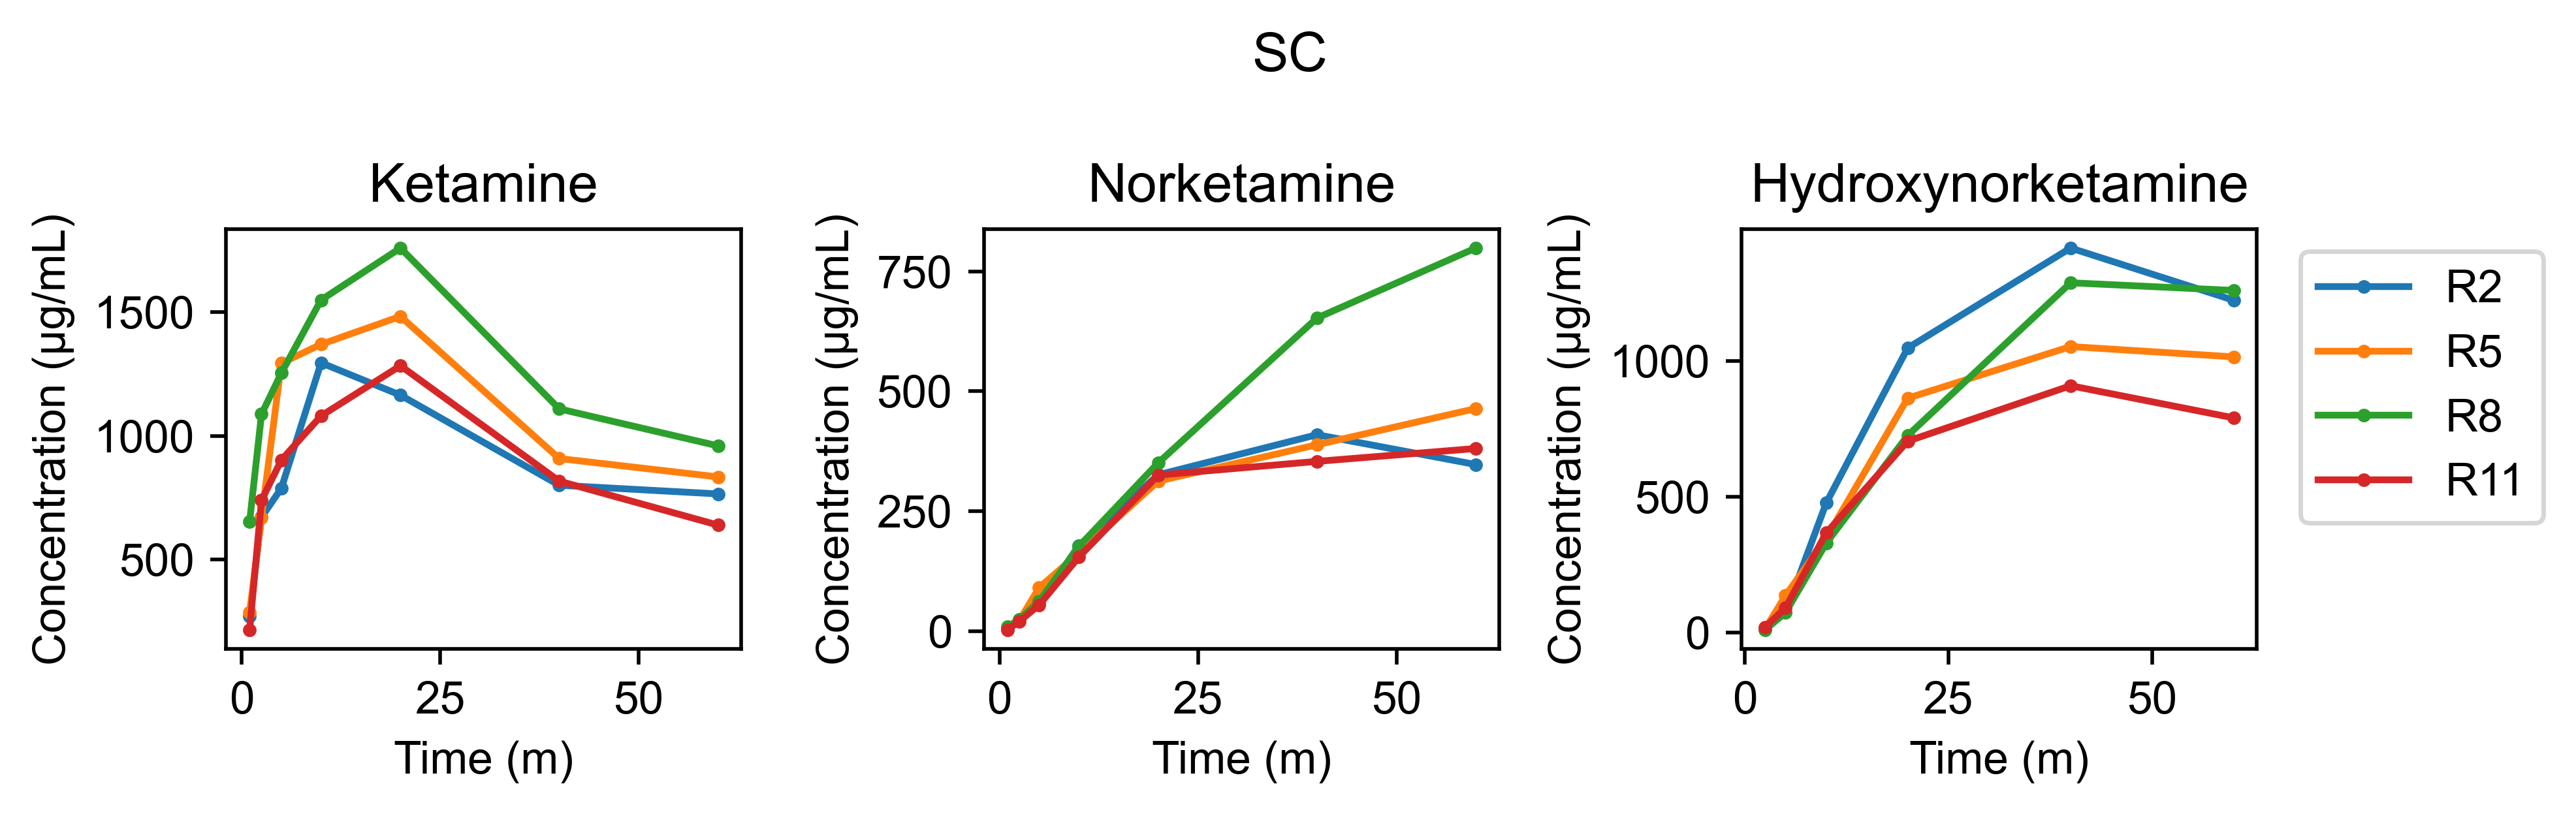

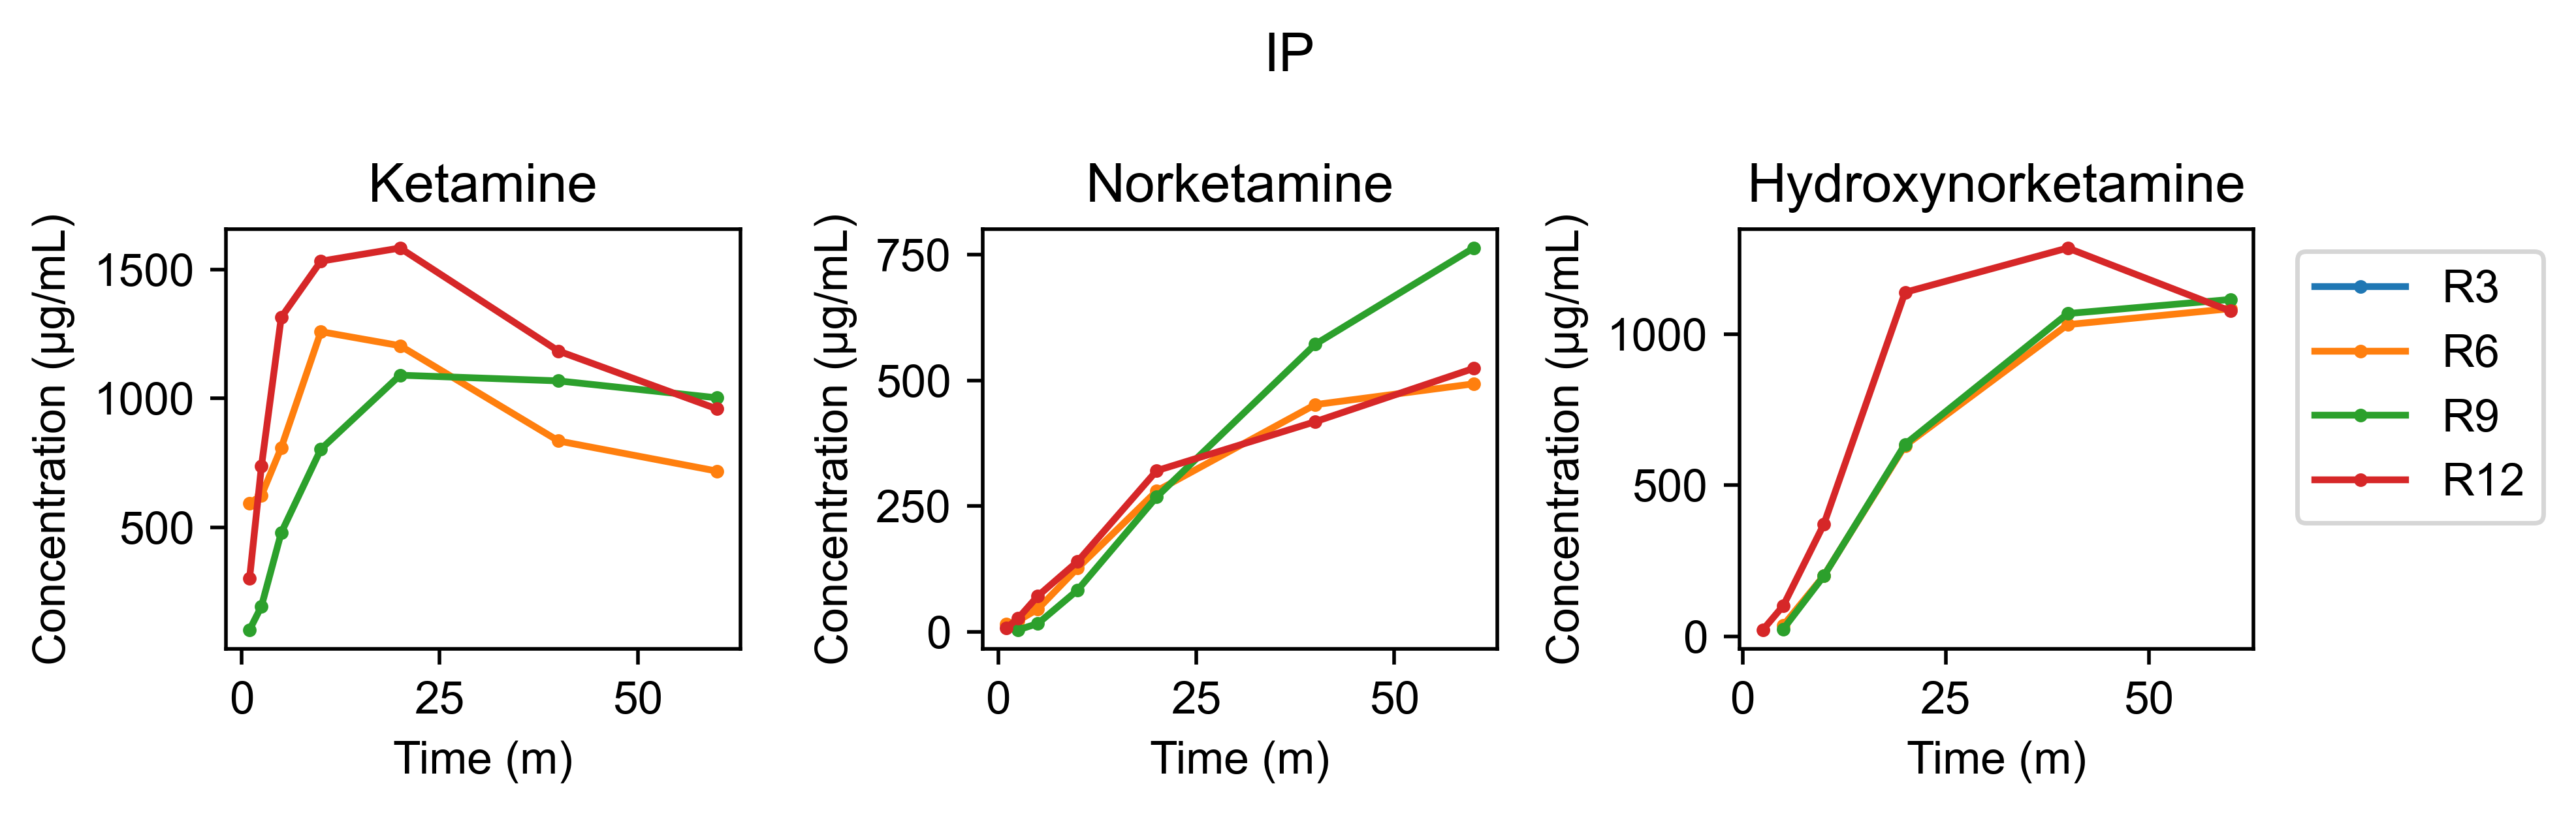

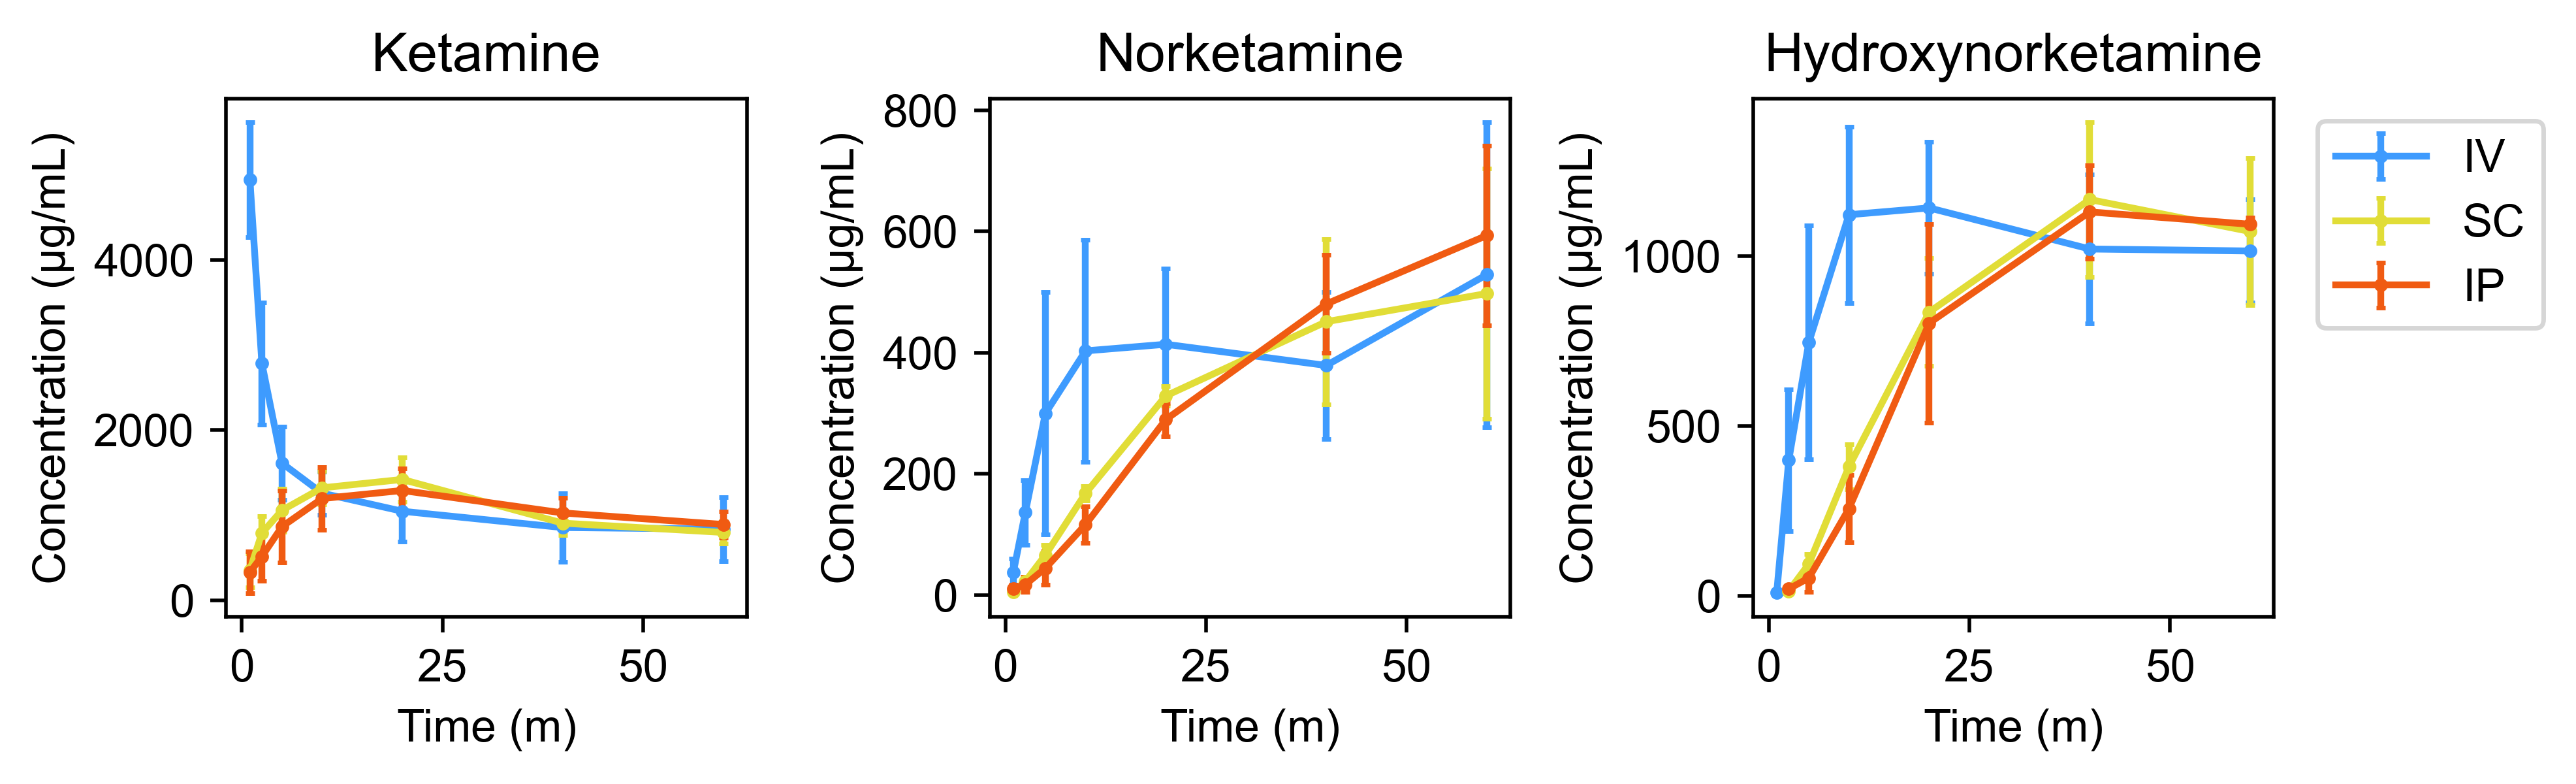

In [283]:
IV=["R1","R4","R7","R10","R13","R14"]
SC=["R2","R5","R8","R11"]
IP=["R3","R6","R9","R12"]

cmap=plt.get_cmap("turbo")

drops_TF=True
save=False
savepath="/Users/snewbank/Documents/PhD/Presentations/24-07-25_year5_committee_mtg/"

groups={"IV" : IV, "SC": SC, "IP": IP}
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]
### Plot individual lines
for k, key in enumerate(groups.keys()):
    fig, ax = plt.subplots(1,3,figsize=(8,2.5),dpi=500)

    pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_ketblood_ROAs.csv"
    df = load_pk(pk_path,drops=drops_TF)

    ax[0].plot(df[IV].index,df[groups[key]]*20,marker="o",markersize=2)
    ax[0].set_xlabel("Time (m)")
    ax[0].set_ylabel("Concentration (μg/mL)")
    ax[0].set_title("Ketamine")

    pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_norketblood_ROAs.csv"
    df = load_pk(pk_path,drops=drops_TF)

    ax[1].plot(df[IV].index,df[groups[key]]*20,marker="o",markersize=2)
    ax[1].set_xlabel("Time (m)")
    ax[1].set_ylabel("Concentration (μg/mL)")
    ax[1].set_title("Norketamine")

    pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_hnkblood_ROAs.csv"
    df = load_pk(pk_path,drops=drops_TF)

    ax[2].plot(df[IV].index,df[groups[key]]*20,marker="o",markersize=2)
    ax[2].set_xlabel("Time (m)")
    ax[2].set_ylabel("Concentration (μg/mL)")
    ax[2].set_title("Hydroxynorketamine")
    ax[2].legend(groups[key],bbox_to_anchor=(1.04, 1), loc="upper left")

    plt.suptitle(key)
    plt.tight_layout()
    
    if save==True:
        plt.savefig(savepath+key+"_pk_individ_dropsFALSE.png",dpi=800)

####Plot average +/- SD
fig, ax = plt.subplots(1,3,figsize=(8,2.5),dpi=500)

pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_ketblood_ROAs.csv"
df = load_pk(pk_path,drops=drops_TF)

ax[0].errorbar(df[IV].index,df[IV].mean(axis=1)*20,yerr=df[IV].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="IV",color=cmap([0.2]))
ax[0].errorbar(df[SC].index,df[SC].mean(axis=1)*20,yerr=df[SC].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="SC",color=cmap([0.6]))
ax[0].errorbar(df[IP].index,df[IP].mean(axis=1)*20,yerr=df[IP].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="IP",color=cmap([0.8]))
ax[0].set_xlabel("Time (m)")
ax[0].set_ylabel("Concentration (μg/mL)")
ax[0].set_title("Ketamine")
#ax[0].legend()

pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_norketblood_ROAs.csv"
df = load_pk(pk_path,drops=drops_TF)

ax[1].errorbar(df[IV].index,df[IV].mean(axis=1)*20,yerr=df[IV].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="IV",color=cmap([0.2]))
ax[1].errorbar(df[SC].index,df[SC].mean(axis=1)*20,yerr=df[SC].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="SC",color=cmap([0.6]))
ax[1].errorbar(df[IP].index,df[IP].mean(axis=1)*20,yerr=df[IP].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="IP",color=cmap([0.8]))
ax[1].set_xlabel("Time (m)")
ax[1].set_ylabel("Concentration (μg/mL)")
ax[1].set_title("Norketamine")
#ax[1].legend()

pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_hnkblood_ROAs.csv"
df = load_pk(pk_path,drops=drops_TF)

ax[2].errorbar(df[IV].index,df[IV].mean(axis=1)*20,yerr=df[IV].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="IV",color=cmap([0.2]))
ax[2].errorbar(df[SC].index,df[SC].mean(axis=1)*20,yerr=df[SC].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="SC",color=cmap([0.6]))
ax[2].errorbar(df[IP].index,df[IP].mean(axis=1)*20,yerr=df[IP].std(axis=1)*20,capsize=1,marker="o",markersize=2,label="IP",color=cmap([0.8]))
ax[2].set_xlabel("Time (m)")
ax[2].set_ylabel("Concentration (μg/mL)")
ax[2].set_title("Hydroxynorketamine")
ax[2].legend(bbox_to_anchor=(1.04, 1), loc="upper left")

plt.tight_layout()
if save==True:
    plt.savefig(savepath+"all_pk_individ_dropsFALSE.png",dpi=800)

IV
[ 3.28619197  3.43734218  0.898945   -1.87473982]
[ 3.4343177   4.52347956  1.77652998 -1.15483196]
[ 3.34645806  4.40061764  1.42490597 -1.24410524]
[ 4.37732768  2.75985837  1.00044185 -2.73236017]
[ 3.4226548   4.60991896  1.42672326 -1.59406755]
[ 3.57339004  3.94624334  1.30550921 -1.72002095]
SC
[2.87027571 3.90779074 0.52158541 0.66023237]
[ 2.72301373  4.36196238  0.51320591 -0.07588938]
[2.70283417 3.91134719 0.50977817 0.64294959]
[2.76537454 4.06036677 0.5148565  0.40909753]
IP
[ 2.75747965  3.76093785  0.46647984 -0.13067067]
[3.09716552 3.09484951 0.250609   0.97477239]
[2.89292708 3.98435473 0.49460467 0.65836627]
[2.91585742 3.6133807  0.40389783 0.50082266]


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: invalid value encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: invalid value encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: invalid value encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)


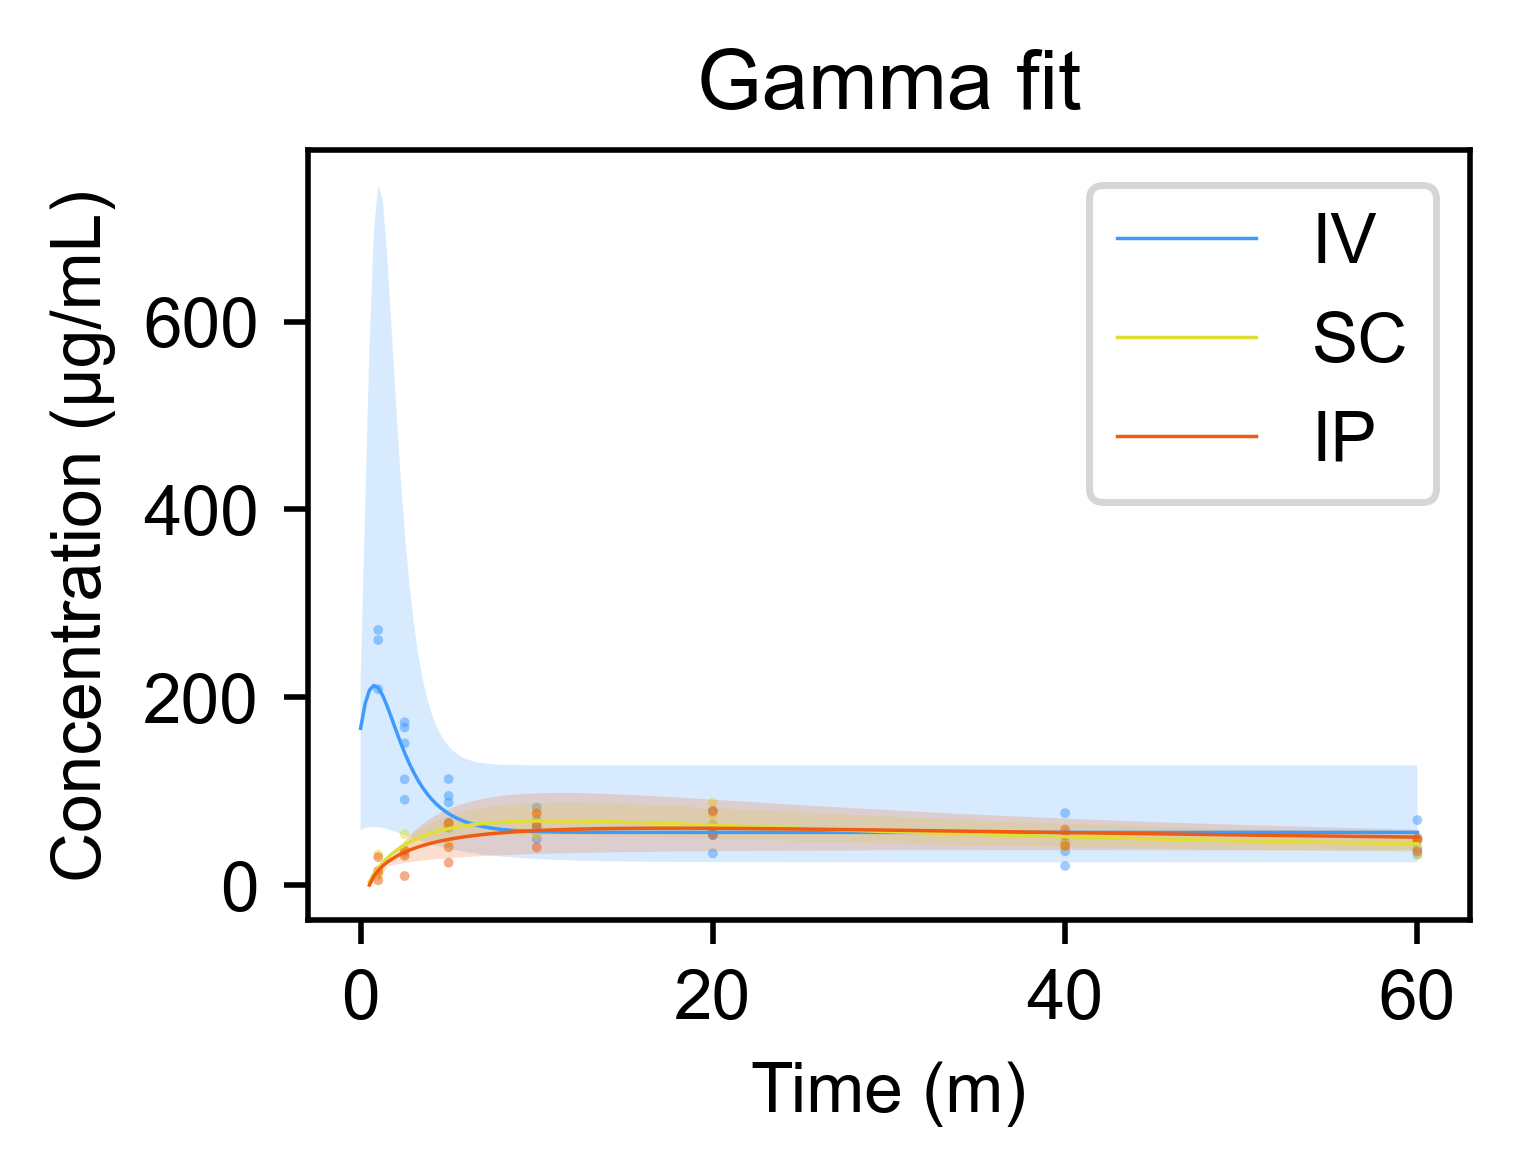

In [284]:
pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_ketblood_ROAs.csv"
drops_TF=True
df = load_pk(pk_path,drops=drops_TF)
plt.figure(figsize=(3,2),dpi=500)

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

def f_exp(x, c, lamb):
    return c*np.exp(-lamb*x)

def f_gamma(x, b_1, b_2, b_3, b_4):
    term1 = b_2**2
    term2 = scipy.special.gamma(b_1)
    term3 = x-b_4
    term4 = b_3*(b_1-1)
    term5 = np.exp(-(term3**b_3)/b_2)
    return term1 * term2 * term3 ** (term4 * term5)

fittype="gamma"

for k, key in enumerate(groups.keys()):
    print(key)
    if k>-1:
        sub_df=df[groups[key]]
        k_label=False
        coeff_all=[]
        for col_num, column in enumerate(sub_df.columns):
            if col_num>0:
                x_dat=[]
                y_dat=[]
                for idx, y in enumerate(sub_df[column].T.values):
                    if not np.isnan(y):
                        x_dat.append(sub_df.index[idx])
                        y_dat.append(y)

                if ((fittype=="trinomial") and (len(y_dat)>0)):
                    coeff = np.polyfit(x_dat,y_dat,3)
                    x = np.linspace(0, 60, 120)
                    y = np.polyval(coeff, x)
                    plt.title('Trinomial fit')

                elif ((fittype=="exp") and (len(y_dat)>0)):
                    coeff, _ = scipy.optimize.curve_fit(f_exp,x_dat,y_dat)

                    x = np.linspace(0, 60, 120)
                    y = f_exp(x,coeff[0],coeff[1])
                    plt.title('Exponential fit')

                elif ((fittype=="gamma") and (len(y_dat)>0)):

                    try:
                        coeff, _ = scipy.optimize.curve_fit(f_gamma,x_dat,y_dat,p0=[3.5, 3, 0.5, 0])
                        print(coeff)
                        #print(coeff)
                        x = np.linspace(0, 60, 240)
                        y = f_gamma(x,coeff[0],coeff[1],coeff[2],coeff[3])
                        coeff_all.append(coeff)
                    except:
                        continue
                    plt.title('Gamma fit')
                try:
                    if k_label==False:
                        #plt.plot(x, y, label=key,color=colors[k],linewidth=0.5)
                        k_label=True
                    else:
                        #plt.plot(x, y, color=colors[k],linewidth=0.5)
                        pass
                    plt.scatter(x_dat,y_dat,s=2,alpha=0.5,edgecolor="none",color=colors[k])
                except:
                    continue
        x = np.linspace(0, 60, 240)
        coeff_all_avg=np.mean(np.array(coeff_all),axis=0)
        coeff_all_std=np.std(np.array(coeff_all),axis=0)
        print(coeff_all_avg)
        y = f_gamma(x,coeff_all_avg[0],coeff_all_avg[1],coeff_all_avg[2],coeff_all_avg[3])
        y_u = f_gamma(x,coeff_all_avg[0]+coeff_all_std[0],coeff_all_avg[1]+coeff_all_std[1],coeff_all_avg[2]+coeff_all_std[2],coeff_all_avg[3]+coeff_all_std[3])
        y_d = f_gamma(x,coeff_all_avg[0]-coeff_all_std[0],coeff_all_avg[1]-coeff_all_std[1],coeff_all_avg[2]-coeff_all_std[2],coeff_all_avg[3]-coeff_all_std[3])
        plt.plot(x, y, label=key,color=colors[k],linewidth=0.5)
        plt.fill_between(x, y_u, y_d, color=colors[k],alpha=0.2,edgecolor="none")
            
    plt.xlabel('Time (m)')
    plt.ylabel('Concentration (μg/mL)')
    plt.legend()
    #plt.ylim([0,100])

In [285]:
'/Users/snewbank/Behavior/MARIPOSA_test/240729_bsoid_allDR'

importlib.reload(analysis)
importlib.reload(plot)

config_path="/Users/snewbank/Behavior/MARIPOSA_test/240729_bsoid_allDR/config.yaml"
save_path="/Users/snewbank/Behavior/MARIPOSA_test/240729_bsoid_allDR/demo/"
save=False

#Load config
config = metadata.load_project(config_path)

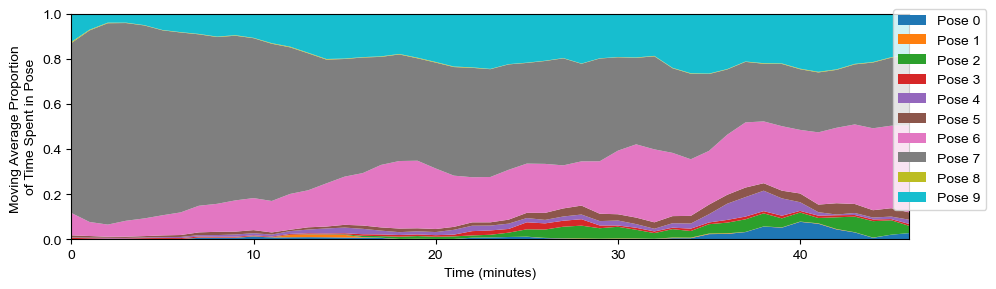

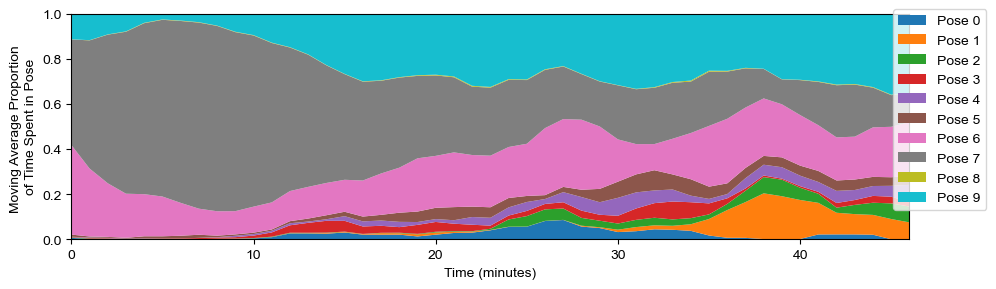

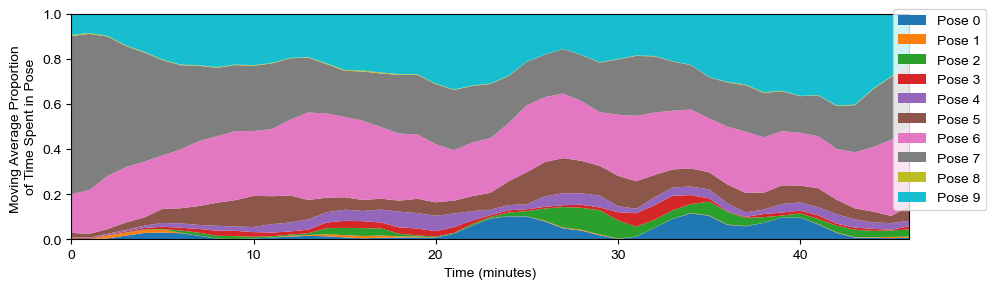

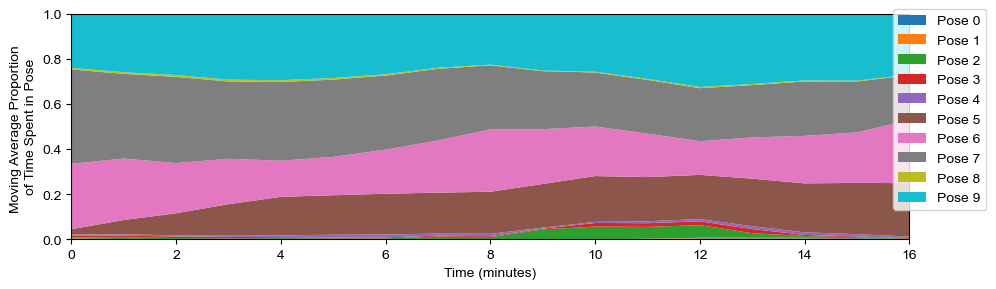

In [286]:
group="sc"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50)
group="iv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50)
group="ip"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50)
group="sal_ip"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 20)

Text(0.5, 0, 'Time (m)')

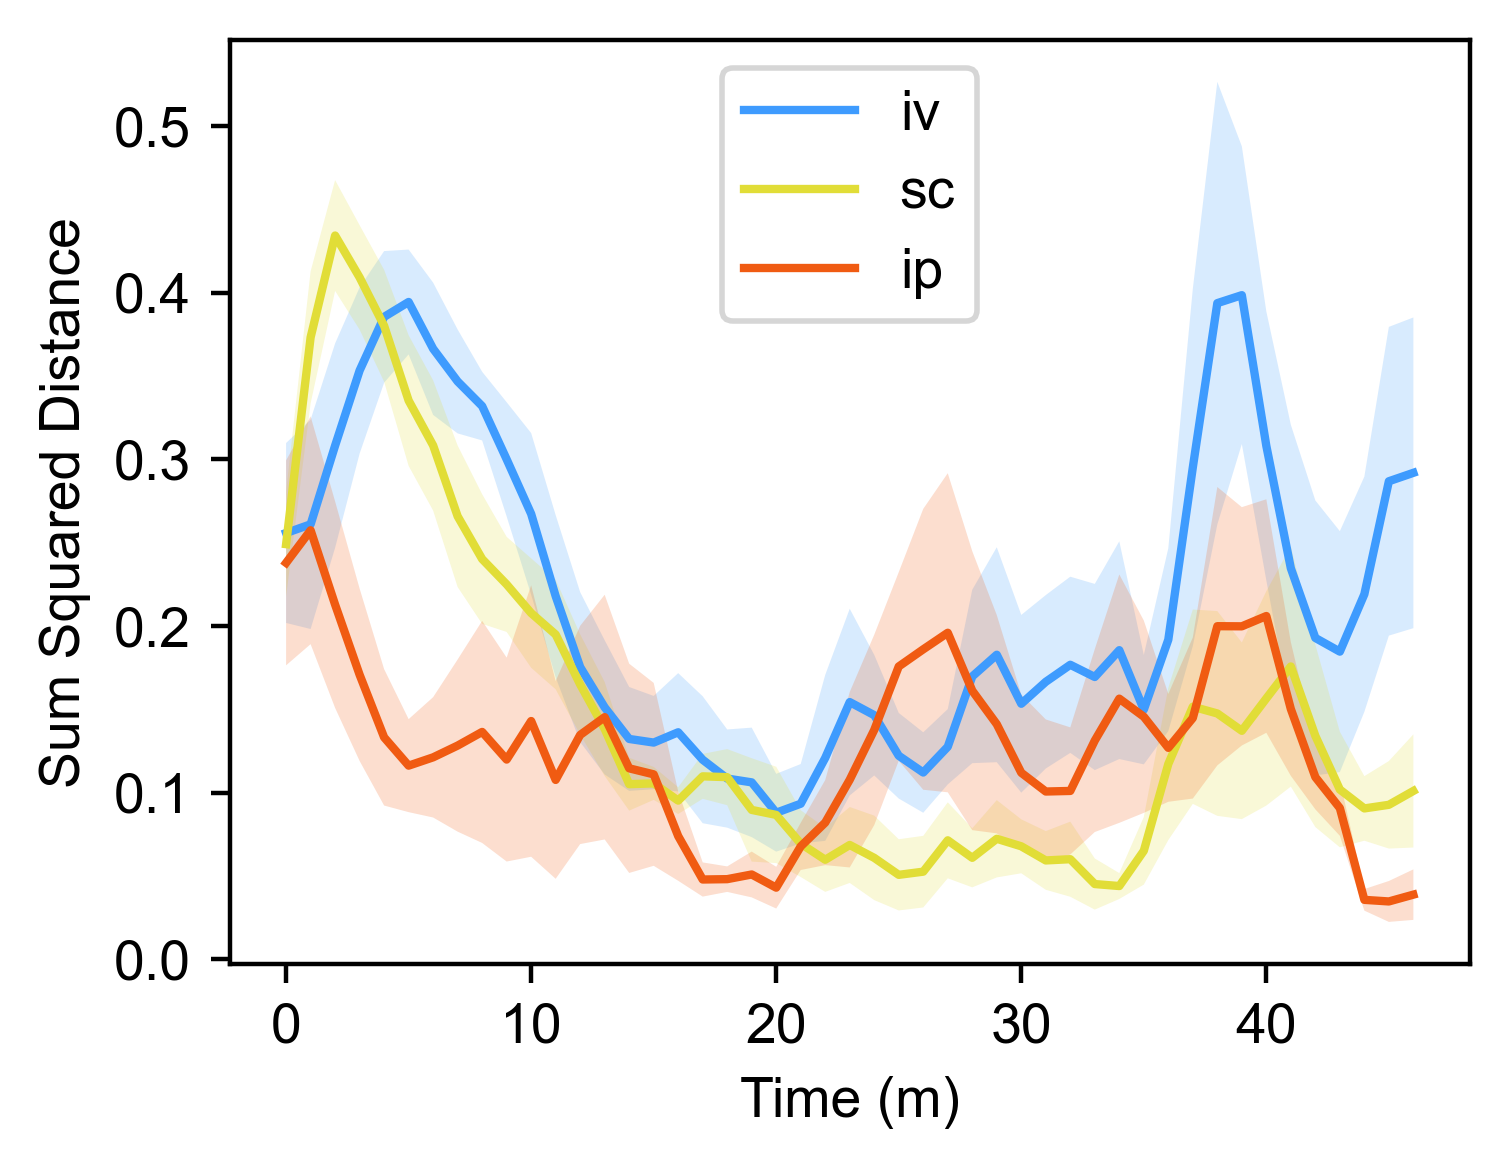

In [287]:
groups=["iv","sc","ip"]
cmap = plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

plt.figure(figsize=(4,3),dpi=400)
for g, group in enumerate(groups):
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
    block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df[group],0, 60, 50)
    block_labels_normal.shape
    
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["sal_iv"])
    label_counts=module_usage_dist(config,labels_df)
    mean_label_counts=np.mean(label_counts,axis=0)
    
    mean_label_counts_block = np.expand_dims(mean_label_counts, axis=1)
    mean_label_counts_block = np.tile(mean_label_counts_block, (1, block_labels_normal.shape[2]))
    
    out=np.zeros_like(block_labels_normal)
    for sess in range(block_labels_normal.shape[0]):
        out[sess,:,:]=np.square(block_labels_normal[sess,:,:]-mean_label_counts_block)
    
    dist=np.sum(out,axis=1)
    xpts=np.arange(0,dist.shape[1],1)
    
    mean = np.mean(dist,axis=0)
    sem = np.std(dist,axis=0)/np.sqrt(dist.shape[0])
    
    plt.plot(xpts,mean,label=group,color=colors[g])
    plt.fill_between(xpts,mean-sem,mean+sem,alpha=0.2,color=colors[g],edgecolor="none")
plt.legend()
plt.ylabel("Sum Squared Distance")
plt.xlabel("Time (m)")

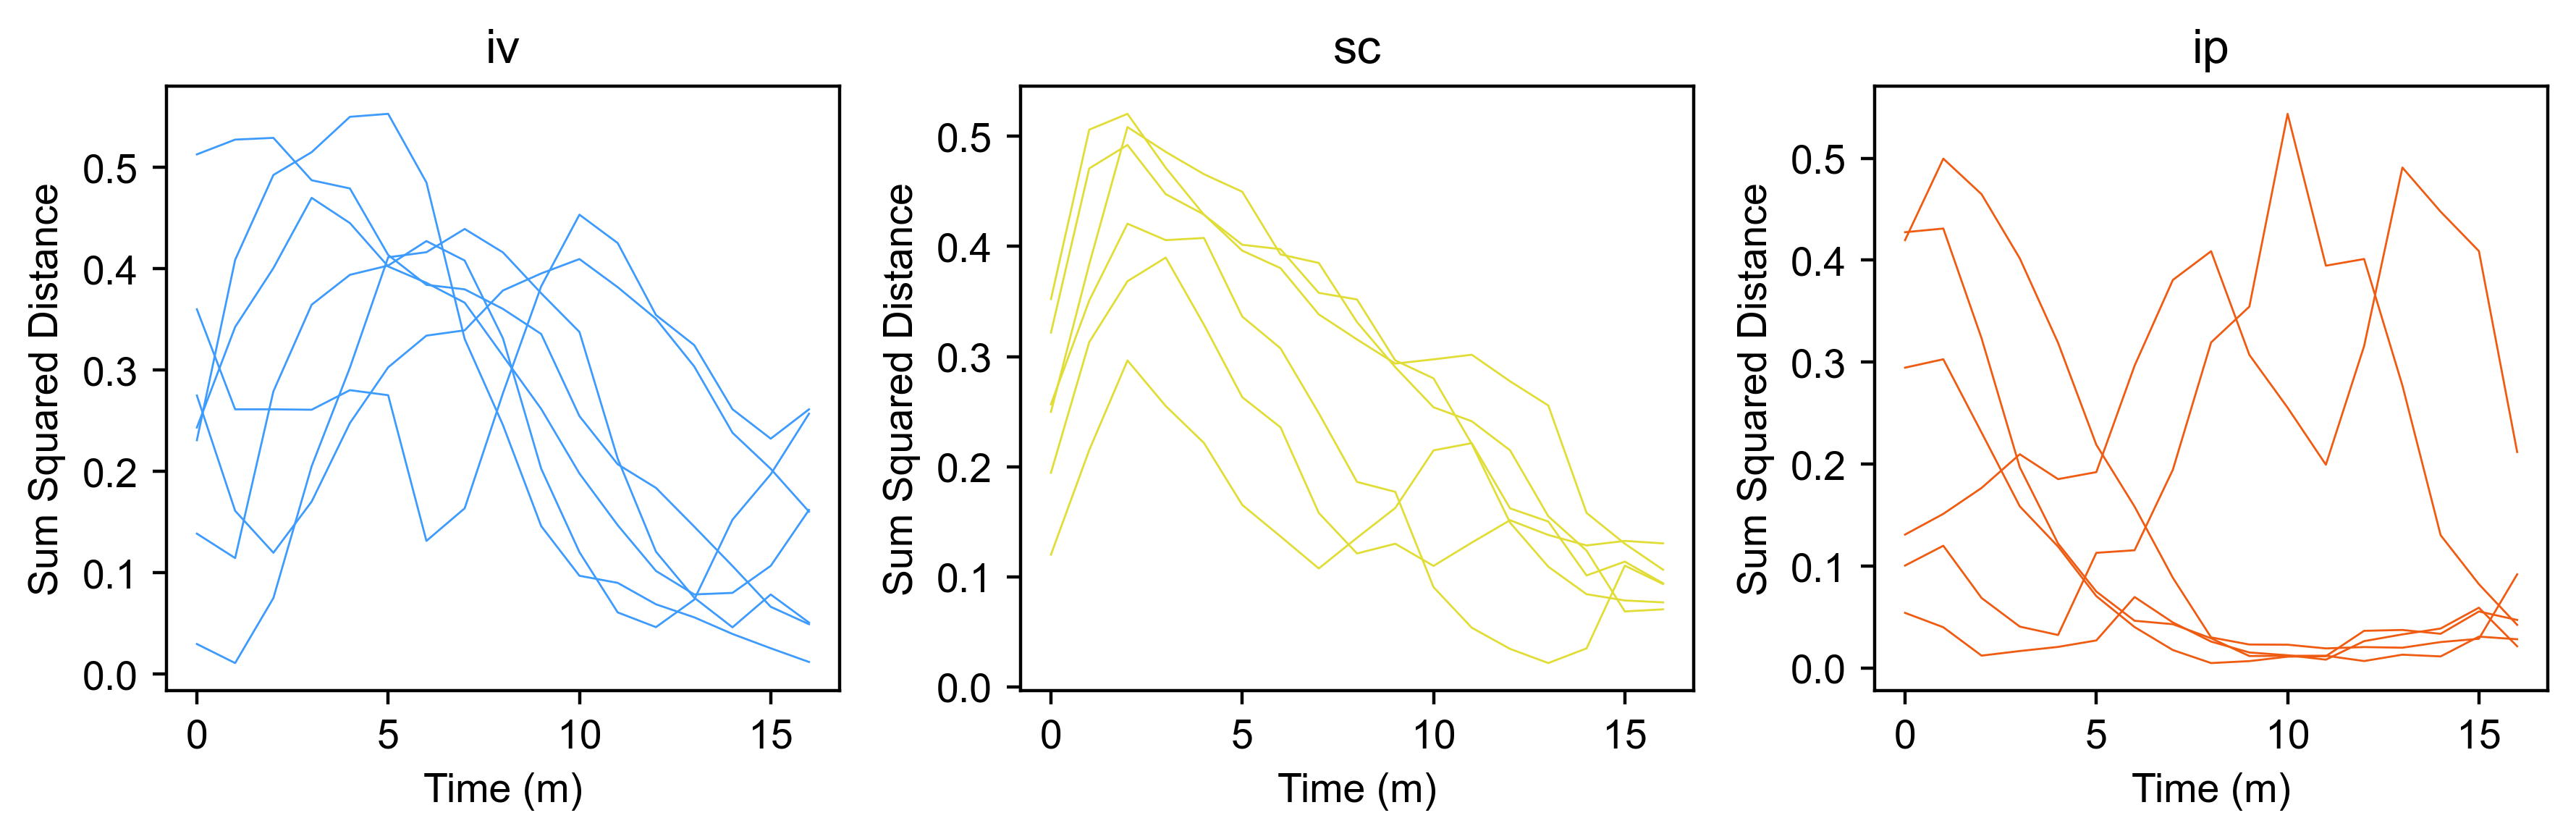

In [288]:
groups=["iv","sc","ip"]
cmap = plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

fig, ax = plt.subplots(1,3,figsize=(9,3),dpi=400)
for g, group in enumerate(groups):
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
    block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df[group],0, 60, 20)
    block_labels_normal.shape
    
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["sal_iv"])
    label_counts=module_usage_dist(config,labels_df)
    mean_label_counts=np.mean(label_counts,axis=0)
    
    mean_label_counts_block = np.expand_dims(mean_label_counts, axis=1)
    mean_label_counts_block = np.tile(mean_label_counts_block, (1, block_labels_normal.shape[2]))
    
    out=np.zeros_like(block_labels_normal)
    for sess in range(block_labels_normal.shape[0]):
        out[sess,:,:]=np.square(block_labels_normal[sess,:,:]-mean_label_counts_block)
    
    dist=np.sum(out,axis=1)
    xpts=np.arange(0,dist.shape[1],1)
    
    mean = np.mean(dist,axis=0)
    sem = np.std(dist,axis=0)/np.sqrt(dist.shape[0])
    for sess in range(dist.shape[0]):
        ax[g].plot(xpts,dist[sess,:],label=group,color=colors[g],linewidth=0.5)
    #plt.fill_between(xpts,mean-sem,mean+sem,alpha=0.2,color=colors[g],edgecolor="none")
    ax[g].set_title(group)
    ax[g].set_ylabel("Sum Squared Distance")
    ax[g].set_xlabel("Time (m)")
plt.tight_layout()

/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in multiply
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: overflow encountered in exp
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in power
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: invalid value encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: divide by zero encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: divide by zero encountered

[ 6.14299531e+00  4.34124830e-02 -6.86464591e-01 -4.31947861e-06]
[-7.99788535  4.44954888  2.26845026 -1.14649862]
[ 5.22884399e+00  1.24603635e-01 -6.06532496e-01 -1.66573931e-06]
[  -5.0000002  1158.2438668     1.28932092  -37.49728684]
[ 8.91240461e-03  4.70114395e-02 -7.17916741e-01 -2.24581615e-05]
[ 1.61281523e-06  5.19278985e-04 -1.85767172e+00 -5.00561152e-06]
[ -7.99999954  15.41566237   0.55266217 -18.4218348 ]


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in multiply
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: overflow encountered in exp
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in power
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: invalid value encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: divide by zero encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: divide by zero encountered

[ -5.99999987 275.47283356   1.03270938 -26.59312709]
[  -5.00000024 1210.90889017    1.33537102  -33.24642066]


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: overflow encountered in scalar multiply
  return term1 * term2 * term3 ** (term4 * term5)


[ 0.97636932 -0.12507878 -0.11214584 -1.98937452]
[ 5.83408894e+00  7.13000024e-02 -7.41422833e-01 -1.24319329e-08]
[  -5.00000014 1355.01948775    1.36963921  -31.26133922]
[ 9.60881513e+00  1.02984776e-03 -1.56638101e+00 -3.65988085e-05]


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in multiply
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: overflow encountered in exp
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in power
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: invalid value encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: divide by zero encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: divide by zero encountered

[-9.00000157  5.44199438  0.44302909 -4.50843605]
[ 6.78170141e+00  2.34680142e-02 -8.09165359e-01 -1.70235110e-05]


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: overflow encountered in divide
  term5 = np.exp(-(term3**b_3)/b_2)


[ 8.53240457e+00  1.51069000e-03 -1.33453080e+00 -4.95792705e-04]
[ 1.11303515e-01 -8.90408662e-04 -2.83826872e+00 -1.57976800e+01]
[ -5.0001031  157.62384046   1.04705982 -14.35282742]
[-7.99456737  7.29765636  1.77379734 -1.06749125]


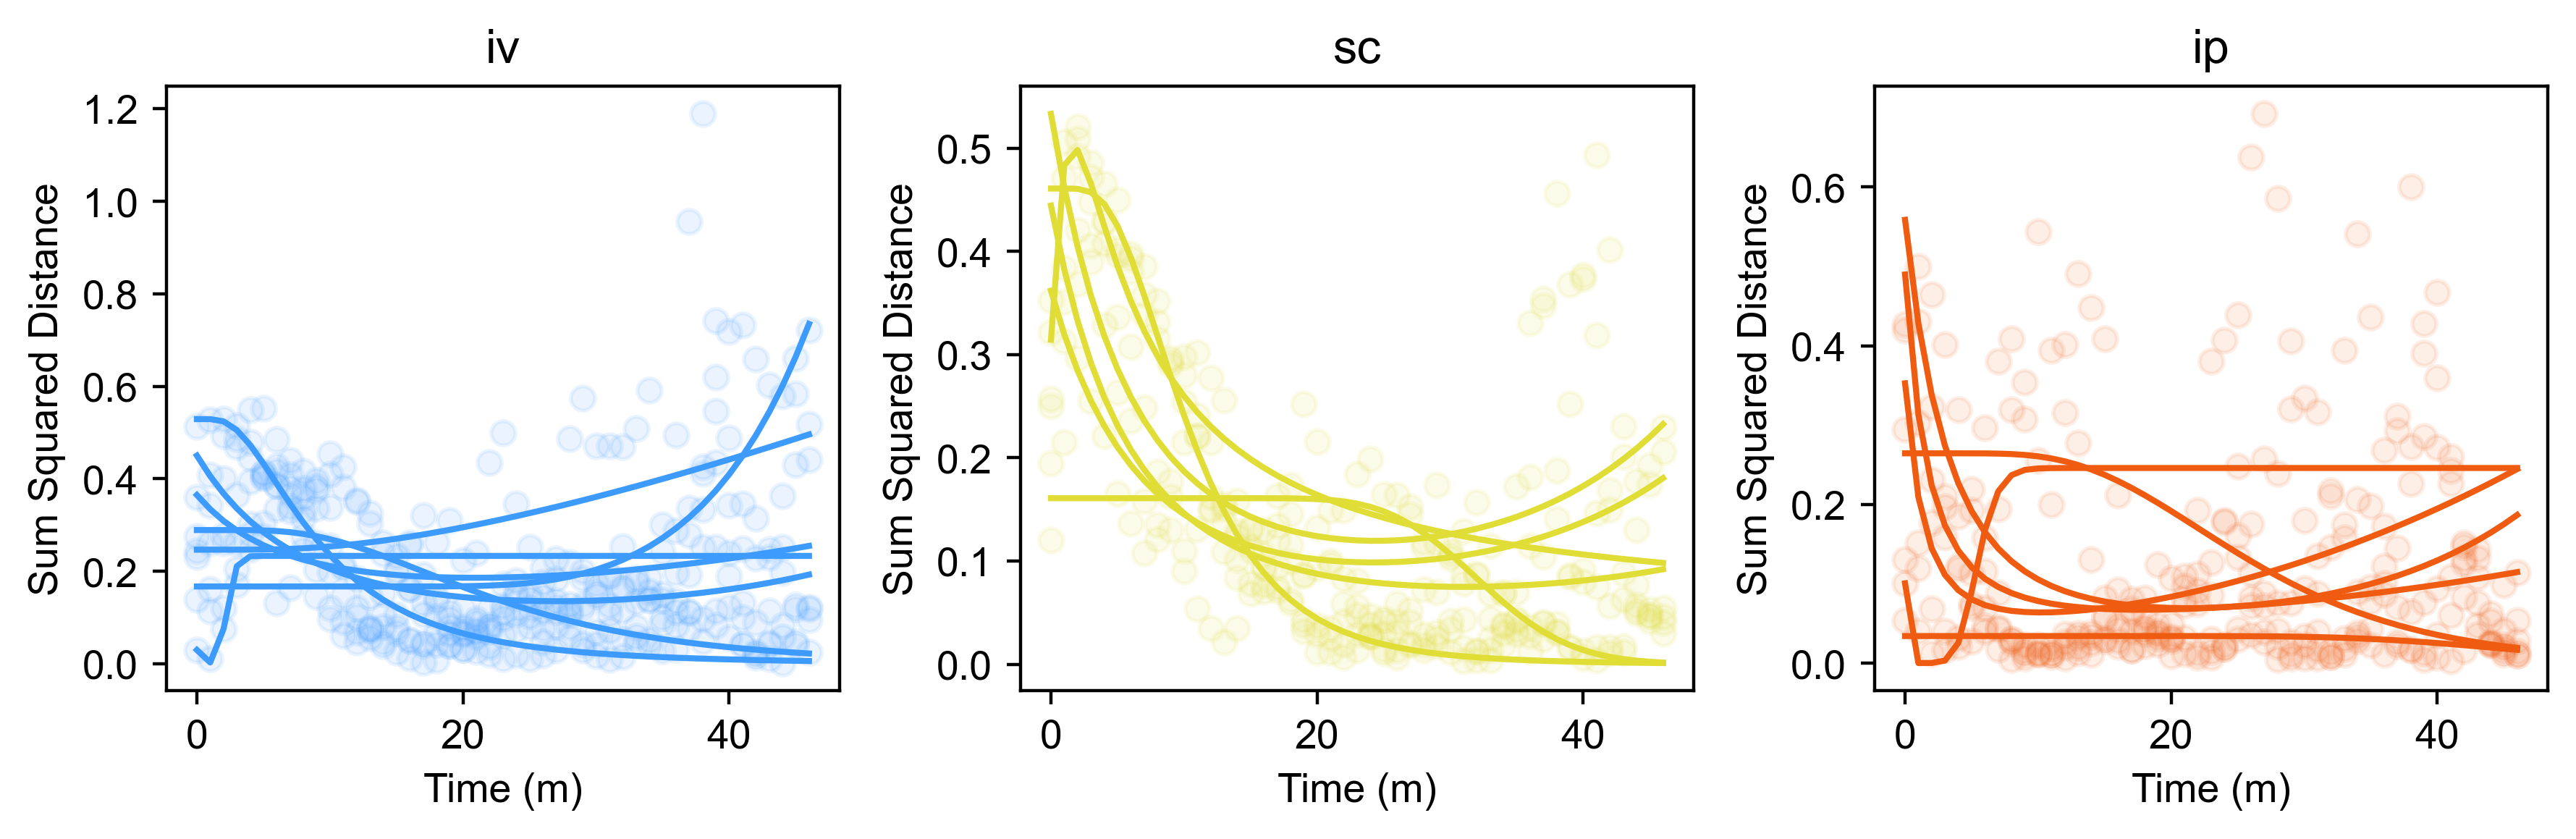

In [234]:
groups=["iv","sc","ip"]
cmap = plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

# Define a cost function to minimize
def cost_function(p0,x,y):
    try:
        coeff, _ = scipy.optimize.curve_fit(f_gamma, x, y, p0=p0)
        return np.sum((y - f_gamma(x,coeff[0],coeff[1],coeff[2],coeff[3]))**2)
    except Exception as e:
        return np.inf  # Return a large value if fitting fails

# Define parameter ranges for grid search
a_range = np.linspace(-10, 10, 10)
b_range = np.linspace(-10, 10, 5)
c_range = np.linspace(-10, 10, 5)
d_range = np.linspace(-3, 3, 6)

fig, ax = plt.subplots(1,3,figsize=(9,3),dpi=400)
for g, group in enumerate(groups):
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
    block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df[group],0, 60, 50)
    block_labels_normal.shape
    
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["sal_iv"])
    label_counts=module_usage_dist(config,labels_df)
    mean_label_counts=np.mean(label_counts,axis=0)
    
    mean_label_counts_block = np.expand_dims(mean_label_counts, axis=1)
    mean_label_counts_block = np.tile(mean_label_counts_block, (1, block_labels_normal.shape[2]))
    
    out=np.zeros_like(block_labels_normal)
    for sess in range(block_labels_normal.shape[0]):
        out[sess,:,:]=np.square(block_labels_normal[sess,:,:]-mean_label_counts_block)
    
    dist=np.sum(out,axis=1)
    xpts=np.arange(0,dist.shape[1],1)
    
    mean = np.mean(dist,axis=0)
    sem = np.std(dist,axis=0)/np.sqrt(dist.shape[0])
    for sess in range(dist.shape[0]):
        ax[g].scatter(xpts,dist[sess,:],label=group,color=colors[g],alpha=0.1)
        best_cost = np.inf
        best_p0 = None
        
        # Grid search
        for a in a_range:
            for b in b_range:
                for c in c_range:
                    for d in d_range:
                        p0 = [a, b, c, d]
                        cost = cost_function(p0,xpts,dist[sess,:])
                        if cost < best_cost:
                            best_cost = cost
                            best_p0 = p0
        coeff, _ = scipy.optimize.curve_fit(f_gamma,xpts,dist[sess,:],p0=best_p0)
        print(coeff)
        y=f_gamma(xpts,coeff[0],coeff[1],coeff[2],coeff[3])
        ax[g].plot(xpts,y,color=colors[g])
    #plt.fill_between(xpts,mean-sem,mean+sem,alpha=0.2,color=colors[g],edgecolor="none")
    ax[g].set_title(group)
    ax[g].set_ylabel("Sum Squared Distance")
    ax[g].set_xlabel("Time (m)")
plt.tight_layout()

/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in multiply
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: overflow encountered in exp
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in power
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: invalid value encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: divide by zero encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: divide by zero encountered

[ 6.14299531e+00  4.34124830e-02 -6.86464591e-01 -4.31947861e-06]
[-7.99788535  4.44954888  2.26845026 -1.14649862]
[ 5.22884399e+00  1.24603635e-01 -6.06532496e-01 -1.66573931e-06]
[  -5.0000002  1158.2438668     1.28932092  -37.49728684]
[ 8.91240461e-03  4.70114395e-02 -7.17916741e-01 -2.24581615e-05]
[ 1.61281523e-06  5.19278985e-04 -1.85767172e+00 -5.00561152e-06]
[ -7.99999954  15.41566237   0.55266217 -18.4218348 ]


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in multiply
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: overflow encountered in exp
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in power
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: invalid value encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: divide by zero encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: divide by zero encountered

[ -5.99999987 275.47283356   1.03270938 -26.59312709]
[  -5.00000024 1210.90889017    1.33537102  -33.24642066]


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: overflow encountered in scalar multiply
  return term1 * term2 * term3 ** (term4 * term5)


[ 0.97636932 -0.12507878 -0.11214584 -1.98937452]
[ 5.83408894e+00  7.13000024e-02 -7.41422833e-01 -1.24319329e-08]
[  -5.00000014 1355.01948775    1.36963921  -31.26133922]
[ 9.60881513e+00  1.02984776e-03 -1.56638101e+00 -3.65988085e-05]


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in multiply
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: overflow encountered in exp
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in power
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: invalid value encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: divide by zero encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: divide by zero encountered

[-9.00000157  5.44199438  0.44302909 -4.50843605]
[ 6.78170141e+00  2.34680142e-02 -8.09165359e-01 -1.70235110e-05]


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: overflow encountered in divide
  term5 = np.exp(-(term3**b_3)/b_2)


[ 8.53240457e+00  1.51069000e-03 -1.33453080e+00 -4.95792705e-04]
[ 1.11303515e-01 -8.90408662e-04 -2.83826872e+00 -1.57976800e+01]
[ -5.0001031  157.62384046   1.04705982 -14.35282742]
[-7.99456737  7.29765636  1.77379734 -1.06749125]


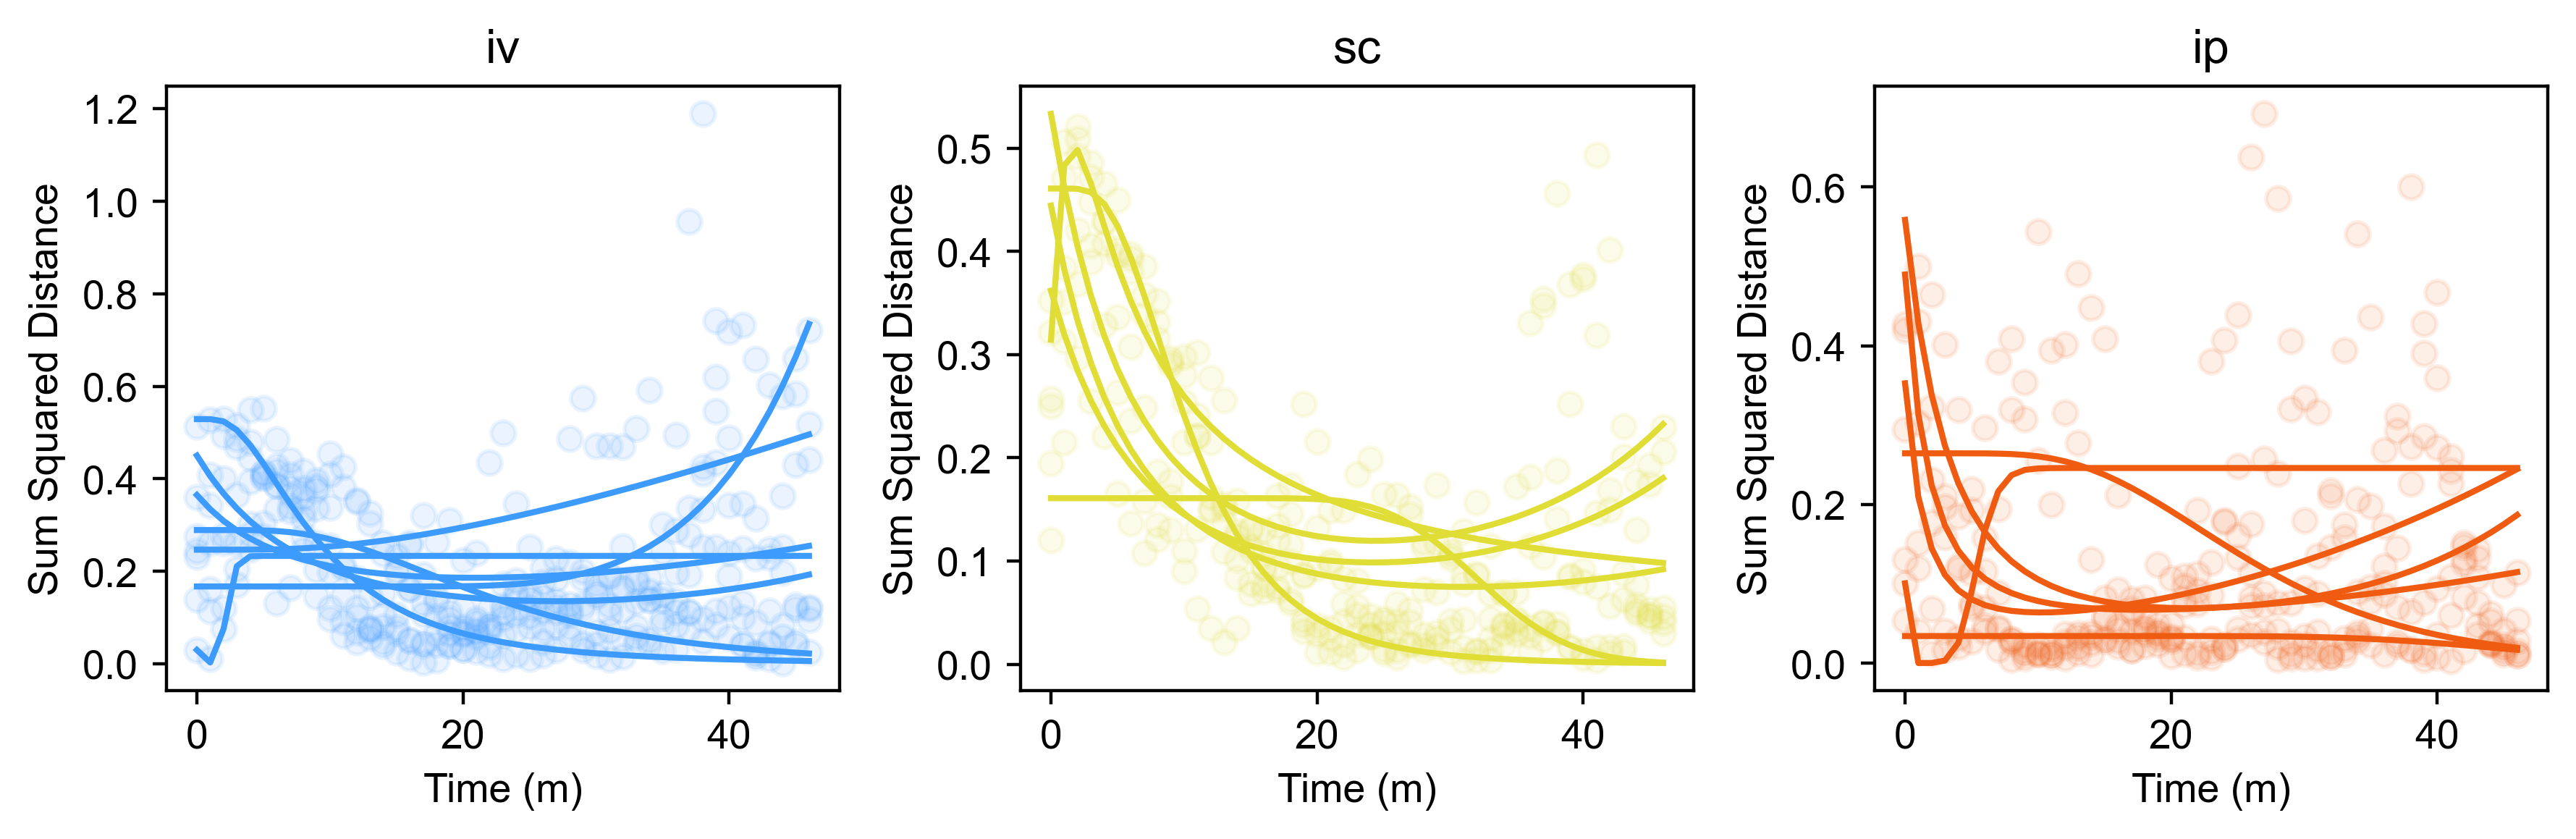

In [316]:
groups=["iv","sc","ip"]
cmap = plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

# Define a cost function to minimize
def cost_function(p0,x,y):
    try:
        coeff, _ = scipy.optimize.curve_fit(f_gamma, x, y, p0=p0)
        return np.sum((y - f_gamma(x,coeff[0],coeff[1],coeff[2],coeff[3]))**2)
    except Exception as e:
        return np.inf  # Return a large value if fitting fails

# Define parameter ranges for grid search
a_range = np.linspace(-10, 10, 10)
b_range = np.linspace(-10, 10, 5)
c_range = np.linspace(-10, 10, 5)
d_range = np.linspace(-3, 3, 6)

fig, ax = plt.subplots(1,3,figsize=(9,3),dpi=400)
for g, group in enumerate(groups):
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
    block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df[group],0, 60, 50)
    block_labels_normal.shape
    
    labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["sal_iv"])
    label_counts=module_usage_dist(config,labels_df)
    mean_label_counts=np.mean(label_counts,axis=0)
    
    mean_label_counts_block = np.expand_dims(mean_label_counts, axis=1)
    mean_label_counts_block = np.tile(mean_label_counts_block, (1, block_labels_normal.shape[2]))
    
    out=np.zeros_like(block_labels_normal)
    for sess in range(block_labels_normal.shape[0]):
        out[sess,:,:]=np.square(block_labels_normal[sess,:,:]-mean_label_counts_block)
    
    dist=np.sum(out,axis=1)
    xpts=np.arange(0,dist.shape[1],1)
    
    mean = np.mean(dist,axis=0)
    sem = np.std(dist,axis=0)/np.sqrt(dist.shape[0])
    for sess in range(dist.shape[0]):
        ax[g].scatter(xpts,dist[sess,:],label=group,color=colors[g],alpha=0.1)
        best_cost = np.inf
        best_p0 = None
        
        # Grid search
        for a in a_range:
            for b in b_range:
                for c in c_range:
                    for d in d_range:
                        p0 = [a, b, c, d]
                        cost = cost_function(p0,xpts,dist[sess,:])
                        if cost < best_cost:
                            best_cost = cost
                            best_p0 = p0
        coeff, _ = scipy.optimize.curve_fit(f_gamma,xpts,dist[sess,:],p0=best_p0)
        print(coeff)
        y=f_gamma(xpts,coeff[0],coeff[1],coeff[2],coeff[3])
        ax[g].plot(xpts,y,color=colors[g])
    #plt.fill_between(xpts,mean-sem,mean+sem,alpha=0.2,color=colors[g],edgecolor="none")
    ax[g].set_title(group)
    ax[g].set_ylabel("Sum Squared Distance")
    ax[g].set_xlabel("Time (m)")
plt.tight_layout()

0


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in multiply
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: overflow encountered in exp
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered in power
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: invalid value encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: divide by zero encountered in divide
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: invalid value encountered

1


/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: divide by zero encountered in power
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: divide by zero encountered in power
  return term1 * term2 * term3 ** (term4 * term5)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:17: RuntimeWarning: invalid value encountered in divide
  term5 = np.exp(-(term3**b_3)/b_2)
/var/folders/v1/8qlykyv97dbb5jhzq44rpdh80000gn/T/ipykernel_74769/2934045153.py:18: RuntimeWarning: overflow encountered in scalar multiply
  return term1 * term2 * term3 ** (term4 * term5)


2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


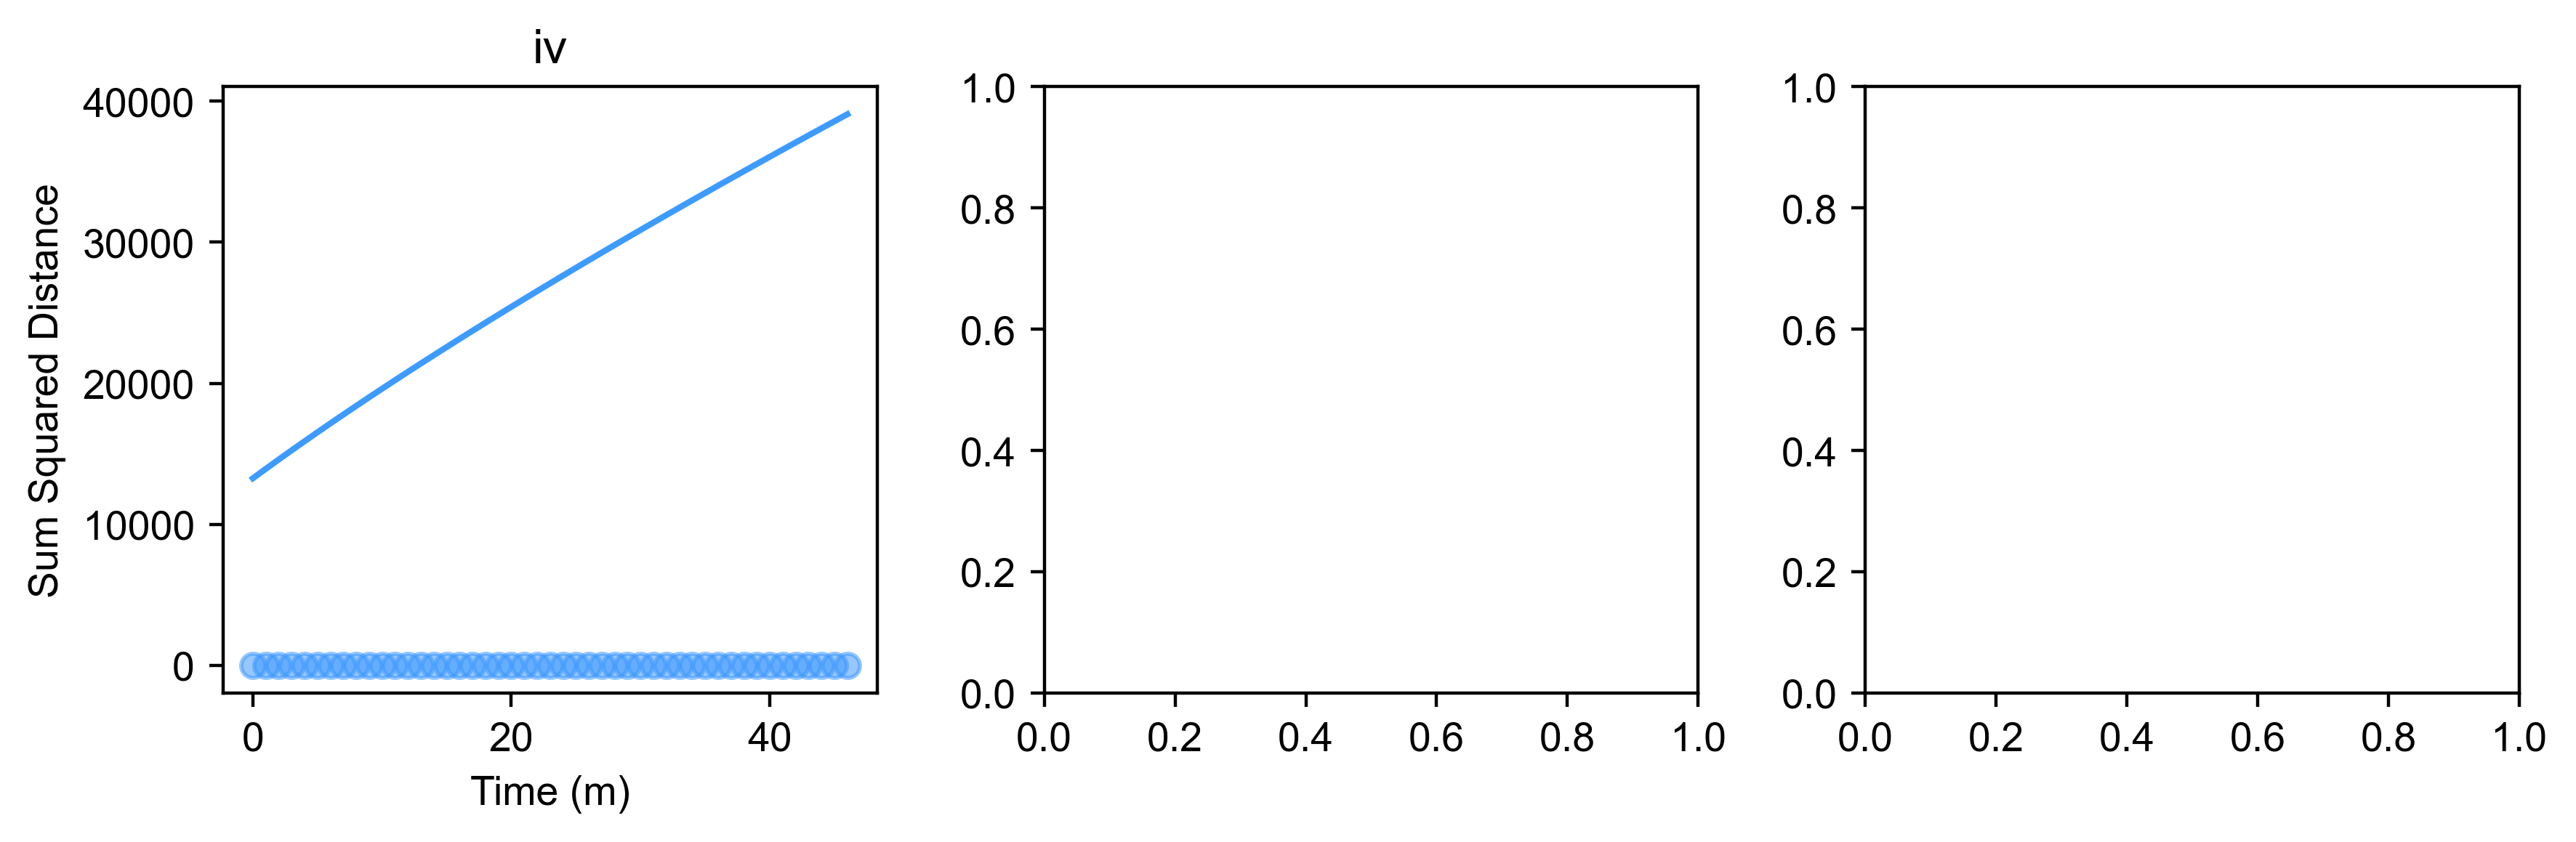

In [315]:
groups=["iv","sc","ip"]
cmap = plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

def cost_function(p0,x,y):
    try:
        coeff, _ = scipy.optimize.curve_fit(f_gamma, x, y, p0=p0)
        return np.sum((y - f_gamma(x,coeff[0],coeff[1],coeff[2],coeff[3]))**2)
    except Exception as e:
        return np.inf

a_range = np.linspace(-10, 10, 10)
b_range = np.linspace(-10, 10, 5)
c_range = np.linspace(-10, 10, 5)
d_range = np.linspace(-3, 3, 6)

fig, ax = plt.subplots(1,3,figsize=(9,3),dpi=400)
for g, group in enumerate(groups):
    if g==0:
        labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
        block_labels_normal_unconv, block_labels_normal = module_usage_density(config, labels_df[group],0, 60, 50)
        block_labels_normal.shape
        
        labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=["sal_iv"])
        label_counts=module_usage_dist(config,labels_df)
        mean_label_counts=np.mean(label_counts,axis=0)
        
        mean_label_counts_block = np.expand_dims(mean_label_counts, axis=1)
        mean_label_counts_block = np.tile(mean_label_counts_block, (1, block_labels_normal.shape[2]))
        
        out=np.zeros_like(block_labels_normal)
        for sess in range(block_labels_normal.shape[0]):
            out[sess,:,:]=np.square(block_labels_normal[sess,:,:]-mean_label_counts_block)
        
        dist=np.sum(out,axis=1)
        xpts=np.arange(0,dist.shape[1],1)
        
        mean = np.mean(dist,axis=0)
        sem = np.std(dist,axis=0)/np.sqrt(dist.shape[0])
        x_fit=np.array([])
        y_fit=np.array([])
        for sess in range(dist.shape[0]):
            #ax[g].scatter(xpts,dist[sess,:],label=group,color=colors[g],alpha=0.1)
            x_fit=np.concatenate((x_fit,xpts))
            y_fit=np.concatenate((y_fit,dist[sess,:]))
        ax[g].scatter(x_fit,y_fit,label=group,color=colors[g],alpha=0.1)
    
        coeff_all=[]
        for i in range(20):
            print(i)
            xy=np.concatenate((np.expand_dims(x_fit,axis=0),np.expand_dims(y_fit,axis=0)),axis=0)
            sample_size=int(xy.shape[1]/10)
            inds = np.random.choice(xy.shape[1], sample_size, replace=False)
            xy_sub=xy[:,inds]
            best_cost = np.inf
            best_p0 = None
            
            # Grid search
            for a in a_range:
                for b in b_range:
                    for c in c_range:
                        for d in d_range:
                            p0 = [a, b, c, d]
                            cost = cost_function(p0,xy_sub[0,:],xy_sub[1,:])
                            if cost < best_cost:
                                best_cost = cost
                                best_p0 = p0
            coeff, _ = scipy.optimize.curve_fit(f_gamma,xy_sub[0,:],xy_sub[1,:],p0=best_p0)
            coeff_all.append(coeff)
        coeff_m=np.mean(coeff_all,axis=0)
        coeff_std=np.std(coeff_all,axis=0)
        y=f_gamma(xpts,coeff_m[0],coeff_m[1],coeff_m[2],coeff_m[3])
        #y_u=f_gamma(xpts,coeff_m[0]+coeff_std[0],coeff_m[1]+coeff_std[1],coeff_m[2]+coeff_std[2],coeff_m[3]+coeff_std[3])
        #y_l=f_gamma(xpts,coeff_m[0]-coeff_std[0],coeff_m[1]-coeff_std[1],coeff_m[2]-coeff_std[2],coeff_m[3]-coeff_std[3])
        ax[g].plot(xpts,y,color=colors[g])
        #ax[g].fill_between(xpts,y_l,y_u,alpha=0.2,color=colors[g],edgecolor="none")
        ax[g].set_title(group)
        ax[g].set_ylabel("Sum Squared Distance")
        ax[g].set_xlabel("Time (m)")
plt.tight_layout()

In [313]:
coeff_all

[array([ 0.71653218, -0.14930222, -1.3597475 , -1.00734073]),
 array([ 0.86236284, -0.18312136, -0.40127434,  0.99999944]),
 array([ 1.09800049e+00,  5.15493189e-01, -2.72552092e+00, -1.64075167e-06]),
 array([ 0.752964  , -0.147449  , -1.96407029,  1.99999886]),
 array([-5.02931807,  7.88383014,  0.52505166, -3.69873048])]

In [138]:
# pk_path="/Users/snewbank/Documents/PhD/Data/24-07-24_bloodPKexpt/24-07-24_ketblood_ROAs.csv"
# drops_TF=True
# df = load_pk(pk_path,drops=drops_TF)
# plt.figure(figsize=(3,2),dpi=500)

# def f_exp(x, c, lamb):
#     return c*np.exp(-lamb*x)

# def f_gamma(x, b_1, b_2, b_3, b_4):
#     term1 = b_2**2
#     term2 = scipy.special.gamma(b_1)
#     term3 = x-b_4
#     term4 = b_3*(b_1-1)
#     term5 = np.exp(-(term3**b_3)/b_2)
#     return term1 * term2 * term3 ** (term4 * term5)

# fittype="gamma"

# for k, key in enumerate(groups.keys()):
#     if k==0:
#         x_dat=[]
#         y_dat=[]
#         print(groups[key])
#         for x in df[groups[key]].T.values:
#             for i in range(len(x)):
#                 if not np.isnan(x[i]):
#                     x_dat.append(df.index[i])
#                     y_dat.append(x[i])

#         if fittype=="trinomial":
#             coeff = np.polyfit(x_dat,y_dat,3)
#             x = np.linspace(0, 60, 120)
#             y = np.polyval(coeff, x)
#             plt.title('Trinomial fit')

#         elif fittype=="exp":
#             coeff, _ = scipy.optimize.curve_fit(f_exp,x_dat,y_dat)

#             x = np.linspace(0, 60, 120)
#             y = f_exp(x,coeff[0],coeff[1])
#             plt.title('Exponential fit')

#         elif fittype=="gamma":
#             coeff, _ = scipy.optimize.curve_fit(f_gamma,x_dat,y_dat,p0=[3, 10, 0.5, 0])
#             print(coeff)
#             x = np.linspace(0, 60, 120)
#             y = f_gamma(x,coeff[0],coeff[1],coeff[2],coeff[3])
#             plt.title('Exponential fit')

#         plt.plot(x, y, label=key)
#         plt.scatter(x_dat,y_dat,s=2,alpha=0.5,edgecolor="none")
# plt.xlabel('Time (m)')
# plt.ylabel('Concentration (μg/mL)')
# plt.legend()